# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

**Objectives**
- Examine the image, text, and policy datasets.
- Assess data quality, class balance, and modelling constraints.
- Prepare reproducible pipelines for classification and policy retrieval.

### 1.1 Load and Explore the RealWaste Dataset

This subsection examines the image dataset's structure, class distribution, and visual characteristics before modelling.

#### Code Brief: Import All Required Libraries

**What the code is doing:** Imports the libraries and utilities required by the notebook.

**Intended achievement:** Makes the environment ready for data processing, modelling, evaluation, visualization, and retrieval.


In [2]:
# IMPORT ALL REQUIRED LIBRARIES

# General utilities
import os
import json
import random
import pathlib
import warnings
from collections import Counter

# Numerical and tabular data
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image, ImageFile, UnidentifiedImageError

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Display utilities
from IPython.display import display

from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer
import faiss

# Allow partially downloaded or truncated images to be inspected
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Suppress non-critical warnings
warnings.filterwarnings("ignore")

# Set consistent chart formatting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"



# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Libraries imported and random seeds configured successfully.")

ModuleNotFoundError: No module named 'sentence_transformers'

#### Code Brief: Load And Explore The Realwaste Dataset

**What the code is doing:** Displays the current outputs, checks, or summary results.

**Intended achievement:** Confirms that the preceding processing step completed as intended.


In [ ]:
## LOAD AND EXPLORE THE REALWASTE DATASET


# Set the path containing the nine waste-category folders
data_dir = pathlib.Path("realwaste/realwaste-main/RealWaste")

# Define the image file formats expected in the dataset
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Confirm that the image directory exists before continuing
if not data_dir.exists():
    raise FileNotFoundError(
        f"Dataset directory not found: {data_dir.resolve()}"
    )

# Identify and sort all waste-category folders
class_names = sorted(
    folder.name for folder in data_dir.iterdir()
    if folder.is_dir()
)

# Validate the expected number of classes
if len(class_names) != 9:
    print(
        f"Warning: Expected 9 waste categories, "
        f"but found {len(class_names)}."
    )

print(f"Dataset location: {data_dir.resolve()}")
print(f"Number of waste categories: {len(class_names)}")
print(f"Waste categories: {class_names}")

Dataset location: D:\D_DESKTOP\Moringa\Module 5\Summative Lab NNs and Similar Models\realwaste\realwaste-main\RealWaste
Number of waste categories: 9
Waste categories: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


#### Code Brief: Create An Image Inventory

**What the code is doing:** Scans the image folders and records each valid file with its waste category.

**Intended achievement:** Creates a structured image inventory for exploration and model preparation.


In [ ]:
# CREATE AN IMAGE INVENTORY


# Store the file path and category of every image
image_records = []

for category in class_names:
    category_dir = data_dir / category

    for file_path in category_dir.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
            image_records.append(
                {
                    "image_path": str(file_path),
                    "category": category,
                    "file_name": file_path.name,
                    "extension": file_path.suffix.lower()
                }
            )

# Convert the inventory into a DataFrame
image_df = pd.DataFrame(image_records)

# Stop execution if no valid image files were found
if image_df.empty:
    raise ValueError(
        "No supported image files were found in the dataset directory."
    )

# Calculate the class distribution
class_distribution = (
    image_df["category"]
    .value_counts()
    .reindex(class_names)
    .rename_axis("category")
    .reset_index(name="image_count")
)

# Add each category's percentage share
class_distribution["percentage"] = (
    class_distribution["image_count"]
    / class_distribution["image_count"].sum()
    * 100
).round(2)

print(f"Total images found: {len(image_df):,}")
display(class_distribution)

Total images found: 4,752


,category,image_count,percentage
0,Cardboard,461,9.70
1,Food Organics,411,8.65
2,Glass,420,8.84
3,Metal,790,16.62
4,Miscellaneous Trash,495,10.42
5,Paper,500,10.52
6,Plastic,921,19.38
7,Textile Trash,318,6.69
8,Vegetation,436,9.18


#### Code Brief: Visualize The Category Distribution

**What the code is doing:** Summarizes category counts and displays them in a bar chart.

**Intended achievement:** Shows class balance and highlights categories that may require modelling attention.


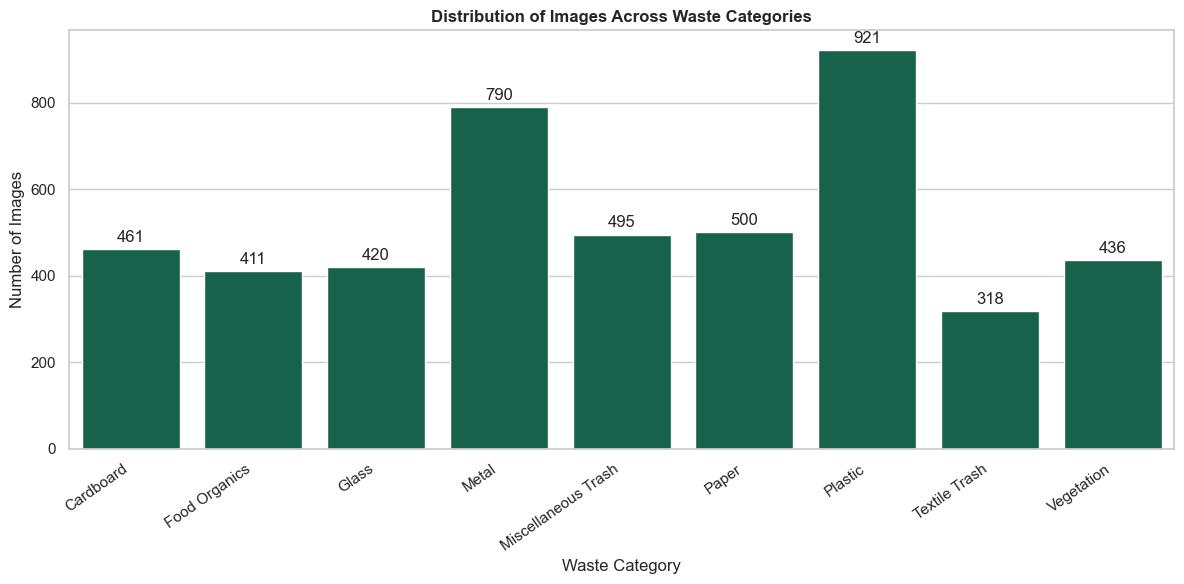

Largest category: Plastic (921 images)
Smallest category: Textile Trash (318 images)
Largest-to-smallest class ratio: 2.90


In [ ]:

## VISUALIZE THE CATEGORY DISTRIBUTION


plt.figure(figsize=(12, 6))

bar_plot = sns.barplot(
    data=class_distribution,
    x="category",
    y="image_count",
    color="#0B6E4F"
)

# Add the number of images above each bar
for container in bar_plot.containers:
    bar_plot.bar_label(container, fmt="%.0f", padding=3)

plt.title("Distribution of Images Across Waste Categories")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Calculate a simple imbalance ratio
largest_class = class_distribution.loc[
    class_distribution["image_count"].idxmax()
]

smallest_class = class_distribution.loc[
    class_distribution["image_count"].idxmin()
]

imbalance_ratio = (
    largest_class["image_count"] / smallest_class["image_count"]
)

print(
    f"Largest category: {largest_class['category']} "
    f"({largest_class['image_count']:,} images)"
)

print(
    f"Smallest category: {smallest_class['category']} "
    f"({smallest_class['image_count']:,} images)"
)

print(f"Largest-to-smallest class ratio: {imbalance_ratio:.2f}")

#### Code Brief: Display One Sample Image From Each Category

**What the code is doing:** Imports the libraries and utilities required by the notebook.

**Intended achievement:** Makes the environment ready for data processing, modelling, evaluation, visualization, and retrieval.


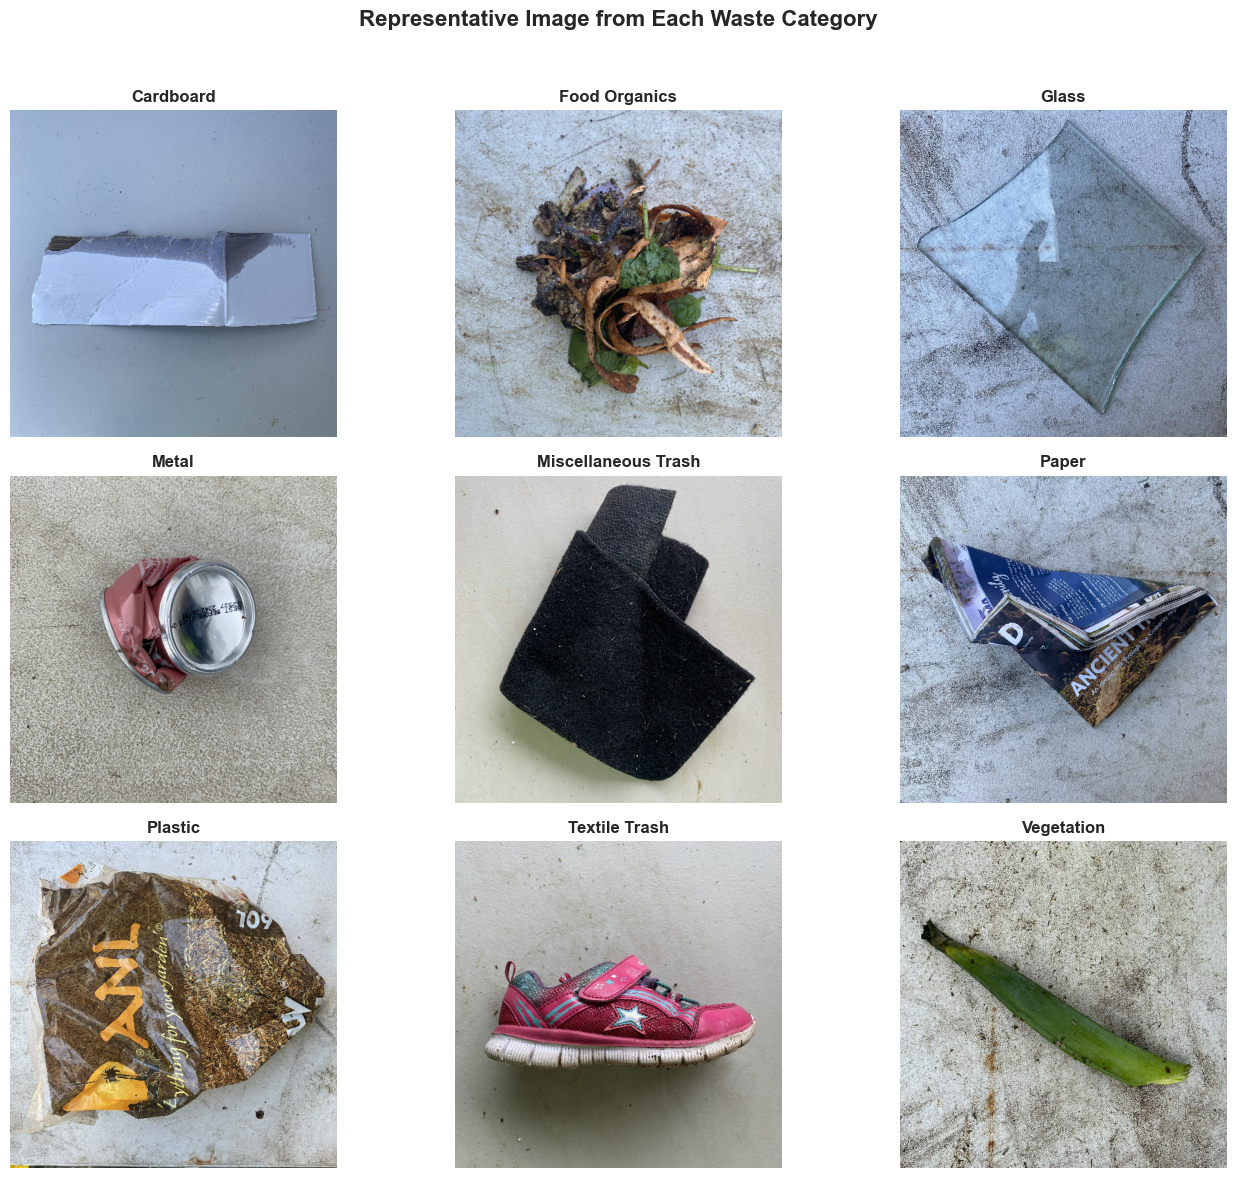

In [ ]:

## DISPLAY ONE SAMPLE IMAGE FROM EACH CATEGORY


fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for index, category in enumerate(class_names):

    # Select one image reproducibly from the category
    category_images = image_df.loc[
        image_df["category"] == category,
        "image_path"
    ]

    sample_path = category_images.sample(
        n=1,
        random_state=SEED
    ).iloc[0]

    # Open and display the selected image
    with Image.open(sample_path) as sample_image:
        axes[index].imshow(sample_image.convert("RGB"))

    axes[index].set_title(category)
    axes[index].axis("off")

plt.suptitle(
    "Representative Image from Each Waste Category",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Code Brief: Analyze Image Characteristics And Check File Quality

**What the code is doing:** Inspects image files, extracts their properties, and checks file integrity.

**Intended achievement:** Identifies unusable files and informs consistent image preprocessing.


In [ ]:

## ANALYZE IMAGE CHARACTERISTICS AND CHECK FILE QUALITY


# Store image dimensions and file-validation results
image_metadata = []
invalid_images = []

for row in image_df.itertuples(index=False):
    try:
        # Open the image and capture its characteristics
        with Image.open(row.image_path) as image:
            width, height = image.size

            image_metadata.append(
                {
                    "image_path": row.image_path,
                    "category": row.category,
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height if height else np.nan,
                    "color_mode": image.mode,
                    "file_size_kb": os.path.getsize(row.image_path) / 1024
                }
            )

            # Verify that the file is not structurally corrupted
            image.verify()

    except (
        UnidentifiedImageError,
        OSError,
        ValueError,
        ZeroDivisionError
    ) as error:
        invalid_images.append(
            {
                "image_path": row.image_path,
                "category": row.category,
                "error": str(error)
            }
        )

# Convert valid image metadata into a DataFrame
image_metadata_df = pd.DataFrame(image_metadata)

# Convert invalid-image results into a DataFrame
invalid_images_df = pd.DataFrame(invalid_images)

print(f"Valid images inspected: {len(image_metadata_df):,}")
print(f"Unreadable or corrupted images: {len(invalid_images_df):,}")

# Display invalid files only if any were detected
if not invalid_images_df.empty:
    display(invalid_images_df.head())

Valid images inspected: 4,752
Unreadable or corrupted images: 0


#### Code Brief: Summarize Image Dimensions, Aspect Ratios, And File Sizes

**What the code is doing:** Inspects image files, extracts their properties, and checks file integrity.

**Intended achievement:** Identifies unusable files and informs consistent image preprocessing.


In [ ]:
# SUMMARIZE IMAGE DIMENSIONS, ASPECT RATIOS, AND FILE SIZES


image_summary = (
    image_metadata_df[
        ["width", "height", "aspect_ratio", "file_size_kb"]
    ]
    .describe()
    .round(2)
)

display(image_summary)

print("\nMost common image resolutions:")

resolution_counts = (
    image_metadata_df
    .assign(
        resolution=image_metadata_df["width"].astype(str)
        + " × "
        + image_metadata_df["height"].astype(str)
    )["resolution"]
    .value_counts()
    .head(10)
    .rename_axis("resolution")
    .reset_index(name="image_count")
)

display(resolution_counts)

print("\nImage color modes:")

color_mode_counts = (
    image_metadata_df["color_mode"]
    .value_counts()
    .rename_axis("color_mode")
    .reset_index(name="image_count")
)

display(color_mode_counts)

,width,height,aspect_ratio,file_size_kb
count,4752.0,4752.0,4752.0,4752.00
mean,524.0,524.0,1.0,141.45
std,0.0,0.0,0.0,39.72
min,524.0,524.0,1.0,47.69
25%,524.0,524.0,1.0,110.87
50%,524.0,524.0,1.0,133.78
75%,524.0,524.0,1.0,174.01
max,524.0,524.0,1.0,242.82



Most common image resolutions:


,resolution,image_count
0,524 × 524,4752



Image color modes:


,color_mode,image_count
0,RGB,4752


#### Code Brief: Visualize Image Width, Height, And Aspect Ratio

**What the code is doing:** Inspects image files, extracts their properties, and checks file integrity.

**Intended achievement:** Identifies unusable files and informs consistent image preprocessing.


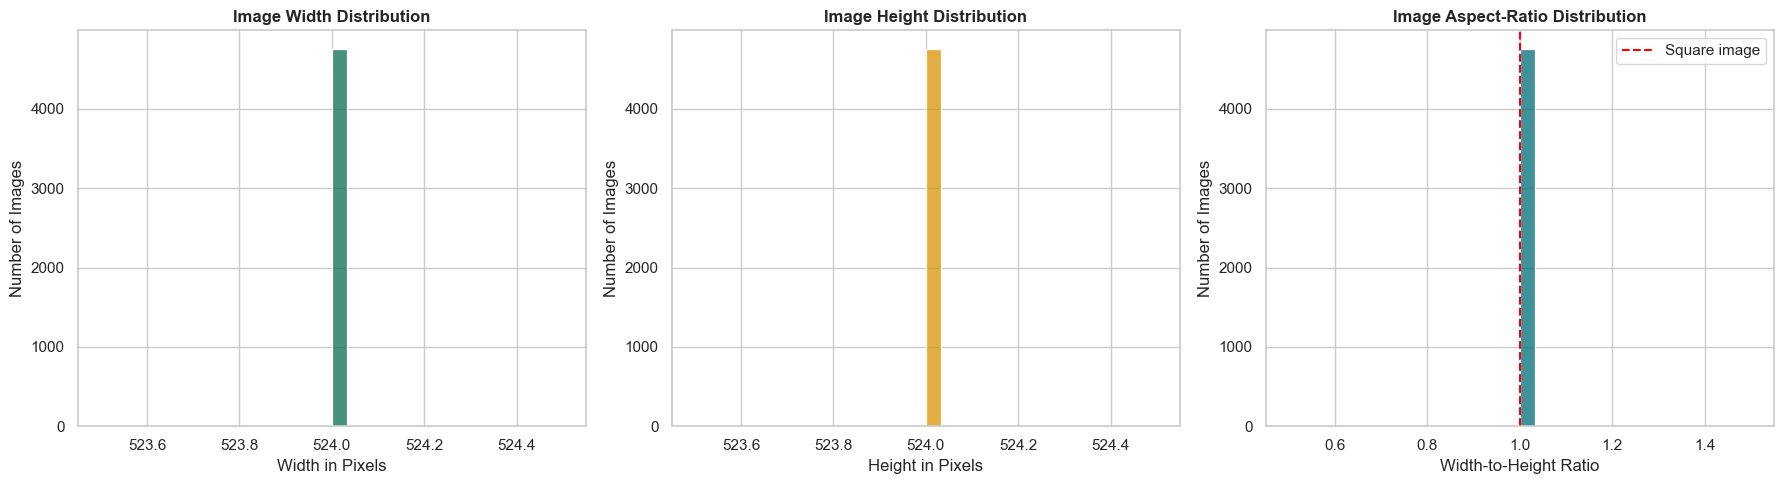

In [ ]:
## VISUALIZE IMAGE WIDTH, HEIGHT, AND ASPECT RATIO


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Width distribution
sns.histplot(
    data=image_metadata_df,
    x="width",
    bins=30,
    color="#0B6E4F",
    ax=axes[0]
)
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width in Pixels")
axes[0].set_ylabel("Number of Images")

# Height distribution
sns.histplot(
    data=image_metadata_df,
    x="height",
    bins=30,
    color="#D99201",
    ax=axes[1]
)
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height in Pixels")
axes[1].set_ylabel("Number of Images")

# Aspect-ratio distribution
sns.histplot(
    data=image_metadata_df,
    x="aspect_ratio",
    bins=30,
    color="#006D77",
    ax=axes[2]
)
axes[2].axvline(
    1.0,
    color="red",
    linestyle="--",
    label="Square image"
)
axes[2].set_title("Image Aspect-Ratio Distribution")
axes[2].set_xlabel("Width-to-Height Ratio")
axes[2].set_ylabel("Number of Images")
axes[2].legend()

plt.tight_layout()
plt.show()

#### Code Brief: Compare Image Characteristics By Waste Category

**What the code is doing:** Inspects image files, extracts their properties, and checks file integrity.

**Intended achievement:** Identifies unusable files and informs consistent image preprocessing.


In [ ]:
## COMPARE IMAGE CHARACTERISTICS BY WASTE CATEGORY

category_characteristics = (
    image_metadata_df
    .groupby("category")
    .agg(
        image_count=("image_path", "count"),
        median_width=("width", "median"),
        median_height=("height", "median"),
        median_aspect_ratio=("aspect_ratio", "median"),
        median_file_size_kb=("file_size_kb", "median")
    )
    .reindex(class_names)
    .round(2)
    .reset_index()
)

display(category_characteristics)

,category,image_count,median_width,median_height,median_aspect_ratio,median_file_size_kb
0,Cardboard,461,524.0,524.0,1.0,112.34
1,Food Organics,411,524.0,524.0,1.0,181.54
2,Glass,420,524.0,524.0,1.0,100.65
3,Metal,790,524.0,524.0,1.0,117.48
4,Miscellaneous Trash,495,524.0,524.0,1.0,138.23
5,Paper,500,524.0,524.0,1.0,121.85
6,Plastic,921,524.0,524.0,1.0,137.87
7,Textile Trash,318,524.0,524.0,1.0,127.42
8,Vegetation,436,524.0,524.0,1.0,199.65


#### Interpretation and Conclusion

The image dataset contains 4,752 valid RGB images across nine classes, all at 524 × 524 pixels. Plastic is the largest class with 921 images, while Textile Trash is the smallest with 318, giving a 2.90 imbalance ratio. The consistent image dimensions simplify preprocessing, but class imbalance and real-world visual variation justify augmentation, transfer learning, and class-level evaluation.

### 1.2 Explore Text Datasets

This subsection assesses the waste descriptions and policy documents for completeness, coverage, and modelling suitability.

#### Code Brief: Load And Explore The Waste Description Dataset

**What the code is doing:** Loads the structured text dataset and checks its contents and quality.

**Intended achievement:** Prepares the waste descriptions for exploration and text classification.


In [ ]:
## LOAD AND EXPLORE THE WASTE DESCRIPTION DATASET

# Load waste descriptions dataset
waste_df = pd.read_csv("waste_descriptions.csv")

# Display basic information
print("=" * 60)
print("WASTE DESCRIPTION DATASET")
print("=" * 60)

print(f"Dataset Shape: {waste_df.shape}")

print("\nColumns:")
for col in waste_df.columns:
    print(f"- {col}")

print("\nMissing Values:")
display(waste_df.isnull().sum())

print("\nSample Records:")
display(waste_df.head())

WASTE DESCRIPTION DATASET
Dataset Shape: (5000, 5)

Columns:
- description
- category
- disposal_instruction
- common_confusion
- material_composition

Missing Values:


description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64


Sample Records:


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...


#### Code Brief: Category Distribution

**What the code is doing:** Summarizes category counts and displays them in a bar chart.

**Intended achievement:** Shows class balance and highlights categories that may require modelling attention.


category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64

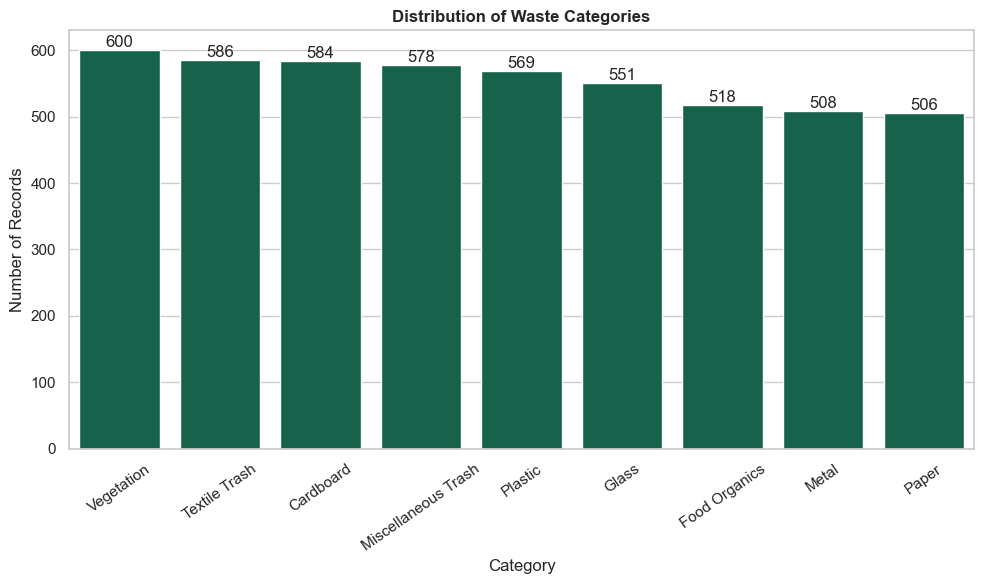

In [ ]:
## CATEGORY DISTRIBUTION


category_counts = (
    waste_df["category"]
    .value_counts()
    .sort_values(ascending=False)
)

display(category_counts)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    color="#0B6E4F"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Waste Categories")
plt.xlabel("Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

#### Code Brief: Text Length Analysis

**What the code is doing:** Measures text length or vocabulary patterns in the available documents.

**Intended achievement:** Assesses text quality and guides feature preparation for NLP modelling.


count    5000.00
mean        4.85
std         1.55
min         1.00
25%         4.00
50%         5.00
75%         6.00
max        10.00
Name: description_word_count, dtype: float64

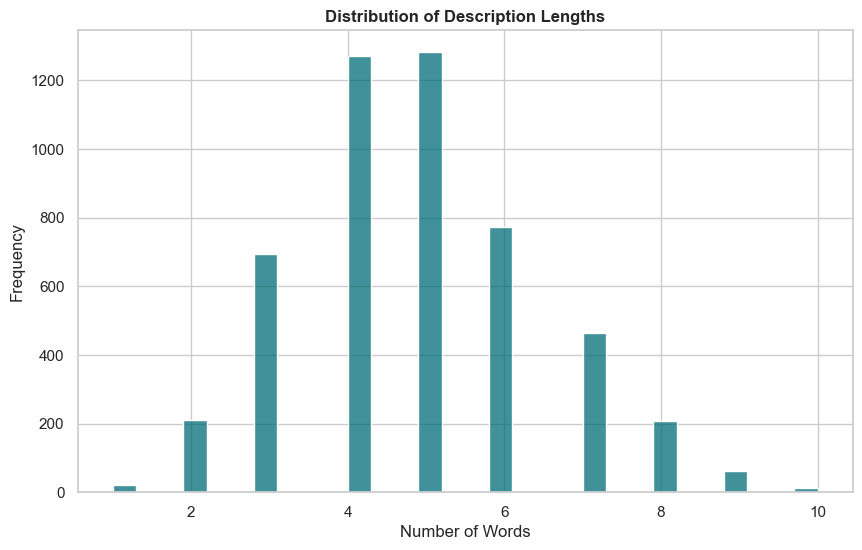

In [ ]:
## TEXT LENGTH ANALYSIS


# Calculate word counts
waste_df["description_word_count"] = (
    waste_df["description"]
    .astype(str)
    .str.split()
    .str.len()
)

display(
    waste_df["description_word_count"]
    .describe()
    .round(2)
)

plt.figure(figsize=(10,6))

sns.histplot(
    waste_df["description_word_count"],
    bins=30,
    color="#006D77"
)

plt.title("Distribution of Description Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

#### Code Brief: Vocabulary Analysis

**What the code is doing:** Imports the libraries and utilities required by the notebook.

**Intended achievement:** Makes the environment ready for data processing, modelling, evaluation, visualization, and retrieval.


,Word,Frequency
0,with,727
1,sized,534
2,glass,424
3,empty,348
4,bottle,342
5,food,316
6,paper,316
7,box,313
8,residue,309
9,plastic,280


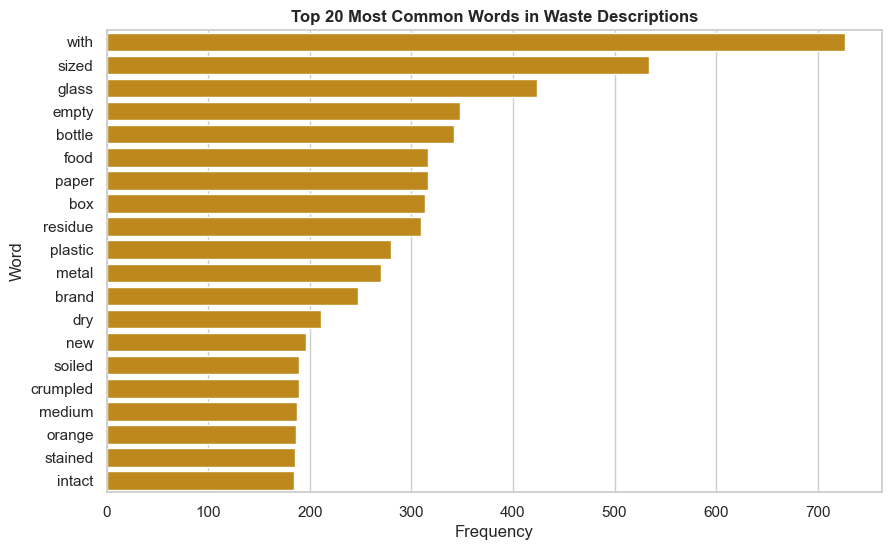

In [ ]:
## VOCABULARY ANALYSIS

from collections import Counter
import re

all_text = " ".join(
    waste_df["description"]
    .astype(str)
    .str.lower()
)

tokens = re.findall(r"\b[a-z]+\b", all_text)

word_freq = Counter(tokens)

common_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

display(common_words)

plt.figure(figsize=(10,6))

sns.barplot(
    data=common_words,
    x="Frequency",
    y="Word",
    color="#D99201"
)

plt.title("Top 20 Most Common Words in Waste Descriptions")

plt.show()

#### Code Brief: Common Confusion Analysis

**What the code is doing:** Displays the current outputs, checks, or summary results.

**Intended achievement:** Confirms that the preceding processing step completed as intended.


In [ ]:
## COMMON CONFUSION ANALYSIS

print(
    "Records containing common confusion information:"
)

print(
    waste_df["common_confusion"]
    .notna()
    .sum()
)

display(
    waste_df[
        [
            "category",
            "common_confusion"
        ]
    ]
    .dropna()
    .head(10)
)

Records containing common confusion information:
2496


,category,common_confusion
4,Food Organics,Meat and dairy products may be restricted in s...
5,Plastic,Plastic bags often can not go in general recyc...
6,Glass,"Window glass, drinking glasses, and ceramics s..."
8,Cardboard,Pizza boxes with food stains should go in orga...
12,Textile Trash,"Some textiles can be recycled or donated, even..."
15,Plastic,Plastic bags often can not go in general recyc...
17,Cardboard,Pizza boxes with food stains should go in orga...
20,Glass,"Window glass, drinking glasses, and ceramics s..."
23,Vegetation,Invasive species may require special disposal....
24,Food Organics,Meat and dairy products may be restricted in s...


#### Code Brief: Load And Explore Policy Documents

**What the code is doing:** Loads and structures the waste-policy documents.

**Intended achievement:** Prepares authoritative policy content for analysis and retrieval.


In [ ]:
## LOAD AND EXPLORE POLICY DOCUMENTS


with open(
    "waste_policy_documents.json",
    "r",
    encoding="utf-8"
) as f:
    policy_docs = json.load(f)

print("=" * 60)
print("POLICY DOCUMENTS")
print("=" * 60)

print(f"Number of Documents: {len(policy_docs)}")

print("\nFirst Document:")
display(pd.DataFrame([policy_docs[0]]))

POLICY DOCUMENTS
Number of Documents: 14

First Document:


,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City


#### Code Brief: Policy Coverage Analysis

**What the code is doing:** Summarizes category counts and displays them in a bar chart.

**Intended achievement:** Shows class balance and highlights categories that may require modelling attention.


,policy_id,policy_type,categories_covered,effective_date
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04
1,2,Glass Recycling Guidelines,[Glass],2023-01-24
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04
5,6,Cardboard Recycling Guidelines,[Cardboard],2023-11-24
6,7,Metal Recycling Guidelines,[Metal],2023-09-03
7,8,Paper Recycling Guidelines,[Paper],2023-10-14
8,9,Miscellaneous Trash Recycling Guidelines,[Miscellaneous Trash],2023-01-01
9,10,Municipal Waste Guidelines,"[Plastic, Miscellaneous Trash, Vegetation]",2023-10-01


Vegetation             4
Metal                  4
Miscellaneous Trash    4
Textile Trash          3
Glass                  3
Plastic                3
Cardboard              3
Food Organics          2
Paper                  1
Name: count, dtype: int64

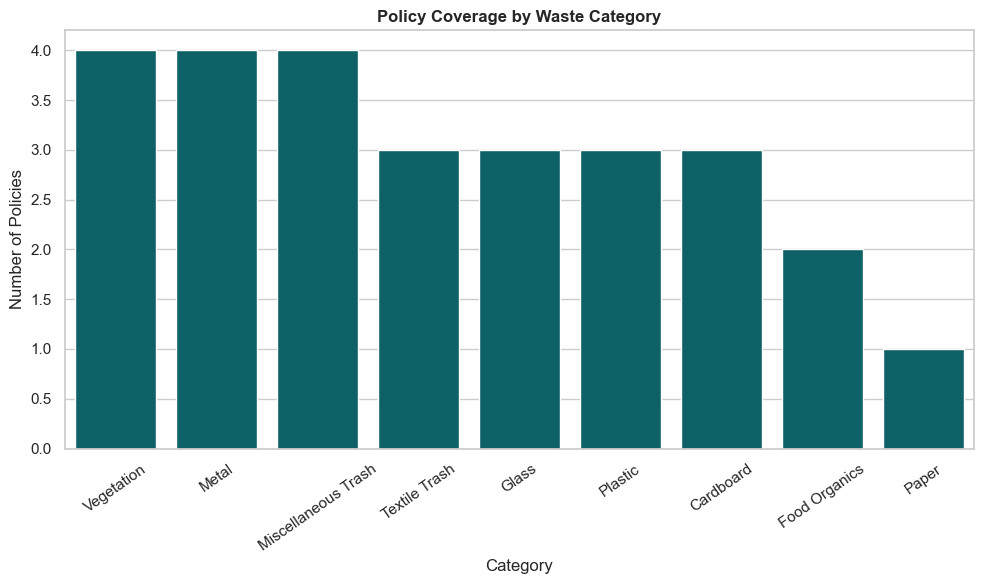

In [ ]:
## POLICY COVERAGE ANALYSIS


policy_summary = pd.DataFrame(policy_docs)

display(
    policy_summary[
        [
            "policy_id",
            "policy_type",
            "categories_covered",
            "effective_date"
        ]
    ]
)

# Count policy coverage by waste category
policy_categories = []

for doc in policy_docs:
    policy_categories.extend(
        doc["categories_covered"]
    )

coverage_df = pd.Series(
    policy_categories
).value_counts()

display(coverage_df)

plt.figure(figsize=(10,6))

sns.barplot(
    x=coverage_df.index,
    y=coverage_df.values,
    color="#006D77"
)

plt.title("Policy Coverage by Waste Category")
plt.xlabel("Category")
plt.ylabel("Number of Policies")

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

#### Code Brief: Policy Document Text Analysis

**What the code is doing:** Loads and structures the waste-policy documents.

**Intended achievement:** Prepares authoritative policy content for analysis and retrieval.


count     14.00
mean     101.79
std       15.12
min       86.00
25%       94.25
50%       99.00
75%      102.00
max      146.00
Name: document_length, dtype: float64

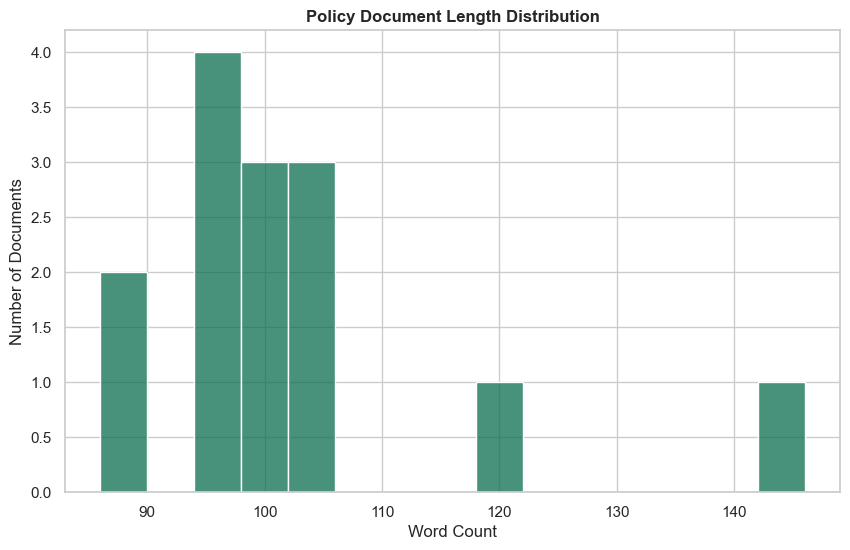

In [ ]:
## POLICY DOCUMENT TEXT ANALYSIS

policy_summary["document_length"] = (
    policy_summary["document_text"]
    .astype(str)
    .str.split()
    .str.len()
)

display(
    policy_summary[
        "document_length"
    ]
    .describe()
    .round(2)
)

plt.figure(figsize=(10,6))

sns.histplot(
    policy_summary["document_length"],
    bins=15,
    color="#0B6E4F"
)

plt.title("Policy Document Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Documents")

plt.show()

#### Interpretation and Conclusion

The text dataset contains 5,000 short descriptions with a mean length of 4.85 words and a reasonably even class distribution. The `common_confusion` field is missing in 2,504 records, so it is useful for qualitative analysis but not as a core model input. The 14 policy documents cover all waste categories, although coverage varies from one policy for Paper to four each for Vegetation, Metal, and Miscellaneous Trash.

### 1.3 Create Data Pipelines

This subsection converts the three datasets into model-ready inputs for the CNN, text classifier, and retrieval system.

#### Code Brief: Run This Code To Setup The Images Properly Into Train, Validation, And Test Sets

**What the code is doing:** Imports the libraries and utilities required by the notebook.

**Intended achievement:** Makes the environment ready for data processing, modelling, evaluation, visualization, and retrieval.


In [ ]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib
data_dir = pathlib.Path(
    "realwaste/realwaste-main/RealWaste"
)

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752
Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


#### Code Brief: Create The Text Preprocessing Pipeline

**What the code is doing:** Imports the libraries and utilities required by the notebook.

**Intended achievement:** Makes the environment ready for data processing, modelling, evaluation, visualization, and retrieval.


In [ ]:
## CREATE THE TEXT PREPROCESSING PIPELINE

# Create a modelling copy of the waste description dataset
text_df = waste_df.copy()

# Retain records with a valid description and category
text_df = text_df.dropna(
    subset=["description", "category"]
).copy()

# Convert descriptions to lowercase and normalize spacing
text_df["clean_description"] = (
    text_df["description"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
)

# Remove any records that became blank after cleaning
text_df = text_df[
    text_df["clean_description"].str.len() > 0
].reset_index(drop=True)

# Confirm that text categories match the image categories
text_class_names = sorted(
    text_df["category"].unique()
)

print(f"Text categories: {text_class_names}")
print(f"Image categories: {class_names}")

assert text_class_names == class_names, (
    "The text and image categories do not match."
)

# Create a consistent category-to-number mapping
text_label_encoder = LabelEncoder()

text_df["label"] = text_label_encoder.fit_transform(
    text_df["category"]
)

# Create an 80% training set and a 20% holdout set
text_train_df, text_holdout_df = train_test_split(
    text_df,
    test_size=0.20,
    stratify=text_df["category"],
    random_state=SEED
)

# Divide the holdout data equally into validation and test sets
text_validation_df, text_test_df = train_test_split(
    text_holdout_df,
    test_size=0.50,
    stratify=text_holdout_df["category"],
    random_state=SEED
)

# Reset indexes after splitting
text_train_df = text_train_df.reset_index(drop=True)
text_validation_df = text_validation_df.reset_index(drop=True)
text_test_df = text_test_df.reset_index(drop=True)

# Summarize the resulting text splits
text_split_summary = pd.DataFrame(
    {
        "Split": [
            "Training",
            "Validation",
            "Test"
        ],
        "Records": [
            len(text_train_df),
            len(text_validation_df),
            len(text_test_df)
        ]
    }
)

text_split_summary["Percentage"] = (
    text_split_summary["Records"]
    / len(text_df)
    * 100
).round(2)

display(text_split_summary)

# Display category distribution across the splits
text_split_distribution = pd.concat(
    [
        text_train_df["category"]
        .value_counts()
        .rename("Training"),

        text_validation_df["category"]
        .value_counts()
        .rename("Validation"),

        text_test_df["category"]
        .value_counts()
        .rename("Test")
    ],
    axis=1
).fillna(0).astype(int).reindex(class_names)

display(text_split_distribution)

# Load the DistilBERT tokenizer
from transformers import AutoTokenizer

text_tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

# Use a practical sequence length for the short descriptions
MAX_TEXT_LENGTH = 64


def tokenize_descriptions(dataframe):
    """
    Tokenizes cleaned waste descriptions for DistilBERT.
    """

    return text_tokenizer(
        dataframe["clean_description"].tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_TEXT_LENGTH,
        return_tensors="np"
    )

# Tokenize each text split separately
train_text_encoding = tokenize_descriptions(
    text_train_df
)

validation_text_encoding = tokenize_descriptions(
    text_validation_df
)

test_text_encoding = tokenize_descriptions(
    text_test_df
)

print("Text preprocessing completed successfully.")
print(
    "Training token shape:",
    train_text_encoding["input_ids"].shape
)
print(
    "Validation token shape:",
    validation_text_encoding["input_ids"].shape
)
print(
    "Test token shape:",
    test_text_encoding["input_ids"].shape
)

Text categories: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Image categories: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


,Split,Records,Percentage
0,Training,4000,80.0
1,Validation,500,10.0
2,Test,500,10.0


,Training,Validation,Test
category,,,
Cardboard,467,58,59
Food Organics,414,52,52
Glass,441,55,55
Metal,407,51,50
Miscellaneous Trash,462,58,58
Paper,405,50,51
Plastic,455,57,57
Textile Trash,469,59,58
Vegetation,480,60,60


Text preprocessing completed successfully.
Training token shape: (4000, 64)
Validation token shape: (500, 64)
Test token shape: (500, 64)


#### Code Brief: Prepare Policy Documents For Rag

**What the code is doing:** Loads and structures the waste-policy documents.

**Intended achievement:** Prepares authoritative policy content for analysis and retrieval.


In [ ]:
## PREPARE POLICY DOCUMENTS FOR RAG

# Convert the loaded policy documents into a DataFrame
policy_df = pd.DataFrame(policy_docs).copy()

# Validate fields required by the retrieval pipeline
required_policy_columns = {
    "policy_id",
    "policy_type",
    "categories_covered",
    "document_text",
    "jurisdiction"
}

missing_policy_columns = (
    required_policy_columns
    - set(policy_df.columns)
)

if missing_policy_columns:
    raise ValueError(
        "Missing required policy columns: "
        f"{sorted(missing_policy_columns)}"
    )

# Replace missing text values
policy_df["policy_type"] = (
    policy_df["policy_type"]
    .fillna("")
    .astype(str)
)

policy_df["document_text"] = (
    policy_df["document_text"]
    .fillna("")
    .astype(str)
)

policy_df["jurisdiction"] = (
    policy_df["jurisdiction"]
    .fillna("")
    .astype(str)
)

# Convert category lists into readable text
policy_df["category_text"] = (
    policy_df["categories_covered"]
    .apply(
        lambda categories: ", ".join(categories)
        if isinstance(categories, list)
        else str(categories)
    )
)

# Combine the relevant fields into retrieval-ready documents
policy_df["retrieval_text"] = (
    "Policy: "
    + policy_df["policy_type"]
    + "\nCategories: "
    + policy_df["category_text"]
    + "\nJurisdiction: "
    + policy_df["jurisdiction"]
    + "\nGuidance: "
    + policy_df["document_text"]
)

# Remove empty and duplicate policy documents
policy_df = (
    policy_df[
        policy_df["retrieval_text"]
        .str.strip()
        .str.len() > 0
    ]
    .drop_duplicates(
        subset=["retrieval_text"]
    )
    .reset_index(drop=True)
)

print(
    "Policy documents prepared:",
    len(policy_df)
)

display(
    policy_df[
        [
            "policy_id",
            "policy_type",
            "category_text",
            "effective_date",
            "jurisdiction"
        ]
    ].head()
)

# Load the sentence embedding model
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

# Generate normalized semantic embeddings
policy_embeddings = embedding_model.encode(
    policy_df["retrieval_text"].tolist(),
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

# Convert embeddings to the data type required by FAISS
policy_embeddings = np.asarray(
    policy_embeddings,
    dtype="float32"
)

# Create a cosine-similarity retrieval index
embedding_dimension = policy_embeddings.shape[1]

policy_index = faiss.IndexFlatIP(
    embedding_dimension
)

# Add all policy embeddings to the index
policy_index.add(policy_embeddings)

print("\nPolicy retrieval index created successfully.")
print(f"Indexed documents: {policy_index.ntotal}")
print(f"Embedding dimensions: {embedding_dimension}")

Policy documents prepared: 14


,policy_id,policy_type,category_text,effective_date,jurisdiction
0,1,Textile Trash Recycling Guidelines,Textile Trash,2023-11-04,Metro City
1,2,Glass Recycling Guidelines,Glass,2023-01-24,Metro City
2,3,Food Organics Recycling Guidelines,Food Organics,2023-05-08,Metro City
3,4,Plastic Recycling Guidelines,Plastic,2023-04-05,Metro City
4,5,Vegetation Recycling Guidelines,Vegetation,2023-12-04,Metro City


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Policy retrieval index created successfully.
Indexed documents: 14
Embedding dimensions: 384


#### Code Brief: Validate The Policy Retrieval Pipeline

**What the code is doing:** Loads and structures the waste-policy documents.

**Intended achievement:** Prepares authoritative policy content for analysis and retrieval.


In [ ]:
# VALIDATE THE POLICY RETRIEVAL PIPELINE


def retrieve_policy_documents(query, top_k=3):
    """
    Retrieves the policy documents most relevant to a query.

    Args:
        query: Waste-management question or search text.
        top_k: Number of policy documents to retrieve.

    Returns:
        DataFrame containing the highest-ranked policies.
    """

    # Limit retrieval to the number of available documents
    top_k = min(top_k, len(policy_df))

    # Convert the query into a normalized embedding
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    query_embedding = np.asarray(
        query_embedding,
        dtype="float32"
    )

    # Search for the most similar policy documents
    similarity_scores, document_indices = (
        policy_index.search(
            query_embedding,
            top_k
        )
    )

    # Build a readable results table
    retrieved_documents = policy_df.iloc[
        document_indices[0]
    ][
        [
            "policy_id",
            "policy_type",
            "category_text",
            "document_text"
        ]
    ].copy()

    retrieved_documents.insert(
        3,
        "similarity_score",
        similarity_scores[0].round(4)
    )

    return retrieved_documents.reset_index(
        drop=True
    )


# Test retrieval using a sample recycling query
sample_query = "How should a glass bottle be recycled?"

sample_retrieval = retrieve_policy_documents(
    sample_query,
    top_k=3
)

print(f"Sample query: {sample_query}")
display(sample_retrieval)

Sample query: How should a glass bottle be recycled?


,policy_id,policy_type,category_text,similarity_score,document_text
0,2,Glass Recycling Guidelines,Glass,0.6668,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...
1,11,Residential Recycling Rules,"Plastic, Metal, Glass, Miscellaneous Trash, Ve...",0.4865,RESIDENTIAL RECYCLING RULES\n\nGENERAL REQUIRE...
2,4,Plastic Recycling Guidelines,Plastic,0.4482,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...


#### Interpretation and Conclusion

The image pipeline produced 119 training, 15 validation, and 15 test batches at 224 × 224 pixels. The text data was split into 4,000 training, 500 validation, and 500 test records using stratification. The 14 policies were embedded into 384-dimensional vectors and indexed in FAISS; the sample glass query correctly ranked the Glass Recycling Guidelines first with a similarity score of 0.6668.

## Part 2: Waste Material Classification with CNN

**Objectives**
- Standardize and augment the waste images.
- Build an EfficientNetB0 transfer-learning classifier.
- Evaluate class-level performance and test whether fine-tuning improves the baseline.

### 2.1 Preprocess Images

This subsection validates the image pipeline and confirms that the training, validation, and test datasets are ready for modelling.

#### Code Brief: Apply The Image Preprocessing Pipeline

**What the code is doing:** Imports the libraries and utilities required by the notebook.

**Intended achievement:** Makes the environment ready for data processing, modelling, evaluation, visualization, and retrieval.


Training batches: 119
Validation batches: 15
Test batches: 15

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32, 9)


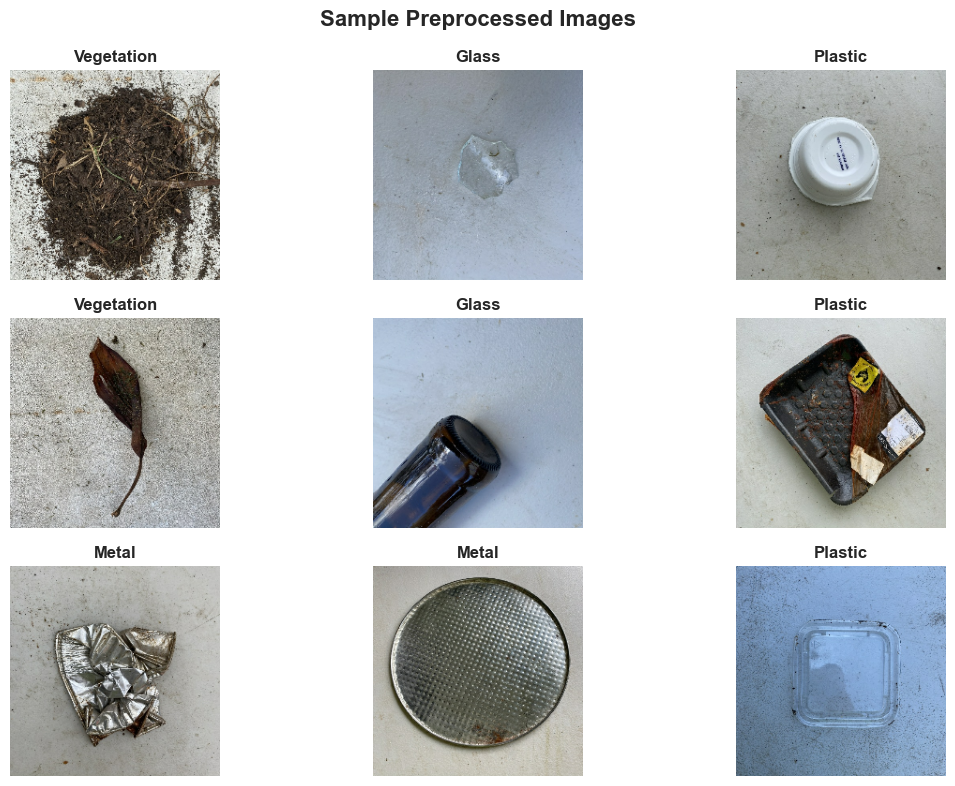

In [ ]:
# APPLY THE IMAGE PREPROCESSING PIPELINE

print("Training batches:",
      tf.data.experimental.cardinality(train_ds).numpy())

print("Validation batches:",
      tf.data.experimental.cardinality(validation_ds).numpy())

print("Test batches:",
      tf.data.experimental.cardinality(test_dataset).numpy())

# Retrieve one batch from the training dataset
sample_images, sample_labels = next(iter(train_ds))

print("\nImage Batch Shape:", sample_images.shape)
print("Label Batch Shape:", sample_labels.shape)

# Display a sample of preprocessed images
plt.figure(figsize=(12, 8))

for i in range(min(9, len(sample_images))):

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        tf.cast(
            tf.clip_by_value(
                sample_images[i],
                0,
                255
            ),
            tf.uint8
        )
    )

    plt.title(
        class_names[
            np.argmax(sample_labels[i].numpy())
        ]
    )

    plt.axis("off")

plt.suptitle(
    "Sample Preprocessed Images",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### Interpretation and Conclusion

The pipeline returns correctly shaped image batches of 32 × 224 × 224 × 3 with one-hot labels for nine classes. Resizing standardizes model input, while augmentation introduces controlled variation to improve generalization.

### 2.2 Implement CNN Model with Transfer Learning

EfficientNetB0 is used to reuse robust visual features while limiting the data and computing required to train the nine-class classifier.

#### Code Brief: Image Augmentation Pipeline

**What the code is doing:** Sets fixed random seeds and shared configuration values.

**Intended achievement:** Makes repeated runs more consistent and reproducible.


In [ ]:
# IMAGE AUGMENTATION PIPELINE

image_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal",
            seed=SEED
        ),
        layers.RandomRotation(
            factor=0.10,
            seed=SEED
        ),
        layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            seed=SEED
        ),
        layers.RandomContrast(
            factor=0.10,
            seed=SEED
        )
    ],
    name="image_augmentation"
)

#### Code Brief: Implement Cnn Model Using Transfer Learning

**What the code is doing:** Builds the CNN image classifier using pretrained or custom feature-extraction layers.

**Intended achievement:** Learns visual patterns needed to classify waste images into the defined categories.


In [ ]:
# IMPLEMENT CNN MODEL USING TRANSFER LEARNING

# Load EfficientNetB0 without its original classifier
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze pre-trained layers during initial training
base_model.trainable = False

# Build the transfer-learning model
cnn_model = keras.Sequential([
    
    # Data augmentation
    image_augmentation,

    # EfficientNet preprocessing
    layers.Lambda(preprocess_input),

    # Pre-trained feature extractor
    base_model,

    # Convert feature maps into a feature vector
    layers.GlobalAveragePooling2D(),

    # Regularization
    layers.BatchNormalization(),

    # Fully connected layer
    layers.Dense(
        512,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),

    # Dropout to reduce overfitting
    layers.Dropout(0.50),

    # Second dense layer
    layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),

    # Additional dropout
    layers.Dropout(0.30),

    # Output layer for 9 classes
    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

# Display model architecture
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_augmentation (Sequential) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

#### Code Brief: Compile The Model

**What the code is doing:** Configures the model optimizer, loss function, and evaluation metrics.

**Intended achievement:** Prepares the neural network for supervised training.


In [ ]:
# COMPILE THE MODEL

cnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

print("CNN model compiled successfully.")


CNN model compiled successfully.


#### Code Brief: Configure Training Callbacks

**What the code is doing:** Defines callbacks for early stopping, learning-rate adjustment, and model saving.

**Intended achievement:** Controls overfitting and preserves the strongest model reached during training.


In [ ]:
# CONFIGURE TRAINING CALLBACKS

early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = callbacks.ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

print("Training callbacks created successfully.")

Training callbacks created successfully.


#### Design Justification

EfficientNetB0 offers a strong accuracy-to-compute trade-off and is appropriate for a moderate-sized dataset. Freezing its pre-trained layers preserves general visual features, while global pooling, L2 regularization, batch normalization, and dropout reduce overfitting in the custom classifier.

### 2.3 Train and Evaluate the Model

The baseline CNN is trained with regularization and evaluated on unseen images using accuracy, class-level metrics, and a confusion matrix.

#### Code Brief: Train The Cnn Model

**What the code is doing:** Defines callbacks for early stopping, learning-rate adjustment, and model saving.

**Intended achievement:** Controls overfitting and preserves the strongest model reached during training.


In [ ]:
# TRAIN THE CNN MODEL

# Configure training callbacks
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = callbacks.ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Train the model
history = cnn_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

print("Model training completed.")

Epoch 1/15

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.5944 - loss: 2.2940
Epoch 1: val_accuracy improved from None to 0.76596, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 59s 445ms/step - accuracy: 0.5944 - loss: 2.2940 - val_accuracy: 0.7660 - val_loss: 1.9017 - learning_rate: 0.0010
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.7433 - loss: 1.8005
Epoch 2: val_accuracy improved from 0.76596 to 0.81702, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 85s 716ms/step - accuracy: 0.7433 - loss: 1.8005 - val_accuracy: 0.8170 - val_loss: 1.6125 - learning_rate: 0.0010
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.7977 - loss: 1.5721
Epoch 3: val_accuracy did not improve from 0.81702
119/119 ━━━━━━━━━━━━━━━━━━━━ 80s 677ms/step - accuracy: 0.7977 - loss: 1.5721 - val_accuracy: 0.8043 

#### Code Brief: Visualize Training Performance

**What the code is doing:** Displays selected images or model results in a visual grid.

**Intended achievement:** Supports visual validation of the data, preprocessing, or predictions.


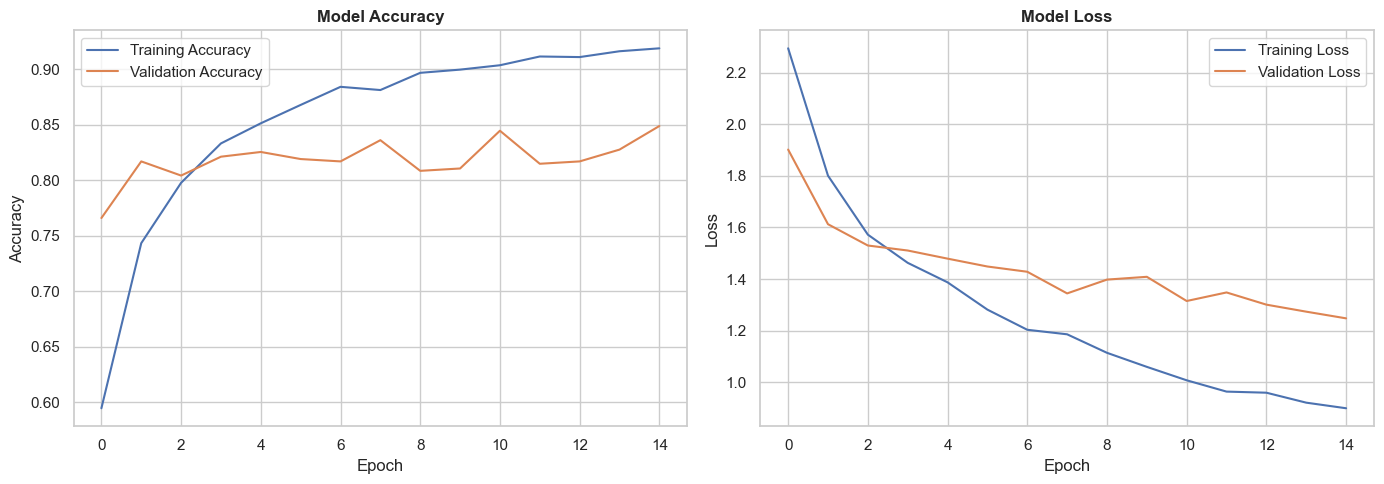

In [ ]:
# VISUALIZE TRAINING PERFORMANCE


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

axes[0].plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(
    history.history["loss"],
    label="Training Loss"
)

axes[1].plot(
    history.history["val_loss"],
    label="Validation Loss"
)

axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Code Brief: Evaluate Model Performance

**What the code is doing:** Evaluates the trained model on held-out test data.

**Intended achievement:** Measures final performance on data that was not used for training.


In [ ]:
# EVALUATE MODEL PERFORMANCE


# Evaluate on the test dataset
test_loss, test_accuracy = cnn_model.evaluate(
    test_dataset,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 436ms/step - accuracy: 0.8500 - loss: 1.1762

Test Loss: 1.1762
Test Accuracy: 0.8500


#### Code Brief: Generate Test Predictions

**What the code is doing:** Uses the trained model to generate category predictions and confidence values.

**Intended achievement:** Tests the model on new inputs and supports reusable inference.


In [ ]:
# GENERATE TEST PREDICTIONS


y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = cnn_model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)


#### Code Brief: Classification Report

**What the code is doing:** Calculates precision, recall, and F1-score for each waste category.

**Intended achievement:** Provides a detailed class-level assessment beyond overall accuracy.


In [ ]:
# CLASSIFICATION REPORT

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                     precision    recall  f1-score   support

          Cardboard       0.71      0.92      0.80        37
      Food Organics       0.94      0.92      0.93        36
              Glass       0.85      0.62      0.72        37
              Metal       0.91      0.90      0.91        93
Miscellaneous Trash       0.86      0.60      0.70        52
              Paper       0.90      0.85      0.88        66
            Plastic       0.74      0.88      0.80        81
      Textile Trash       0.87      0.95      0.91        43
         Vegetation       0.95      1.00      0.97        35

           accuracy                           0.85       480
          macro avg       0.86      0.85      0.85       480
       weighted avg       0.86      0.85      0.85       480



#### Code Brief: Confusion Matrix

**What the code is doing:** Creates a confusion matrix comparing actual and predicted categories.

**Intended achievement:** Reveals which waste classes are correctly identified or commonly confused.


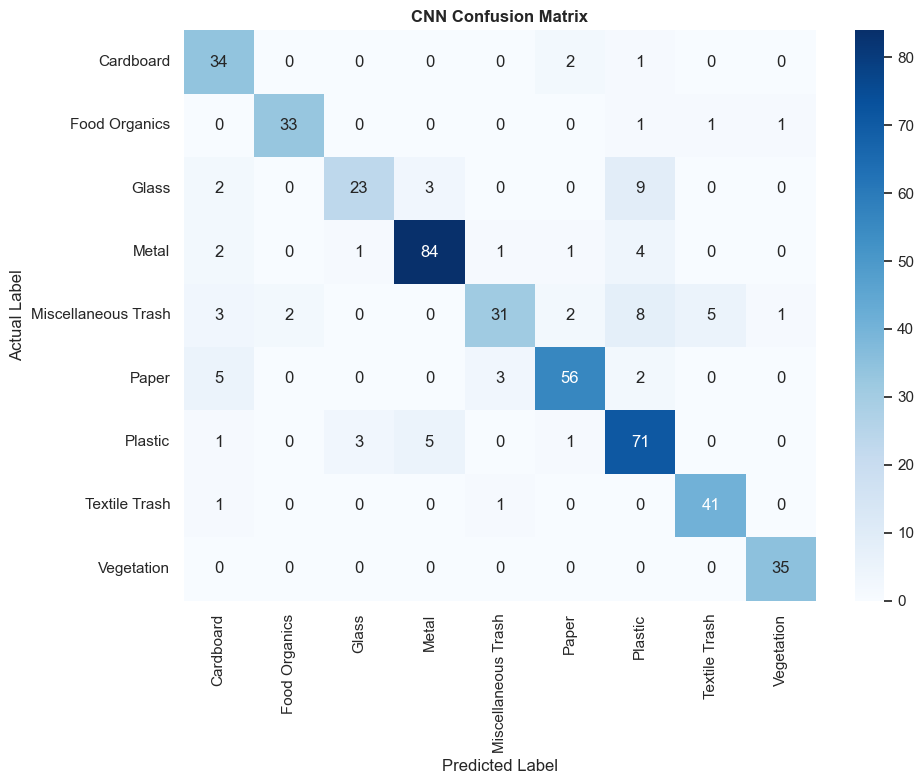

In [ ]:
# CONFUSION MATRIX


cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

#### Code Brief: Identify Challenging Categories

**What the code is doing:** Aggregates the relevant records and displays summary statistics.

**Intended achievement:** Turns raw data into interpretable evidence for analysis and modelling decisions.


In [ ]:
# IDENTIFY CHALLENGING CATEGORIES


category_accuracy = (
    cm.diagonal()
    / cm.sum(axis=1)
)

category_performance = pd.DataFrame({
    "Category": class_names,
    "Accuracy": category_accuracy
})

category_performance = (
    category_performance
    .sort_values(
        "Accuracy",
        ascending=True
    )
)

display(category_performance)

print(
    "\nMost challenging categories:"
)

display(
    category_performance.head(3)
)

,Category,Accuracy
4,Miscellaneous Trash,0.596154
2,Glass,0.621622
5,Paper,0.848485
6,Plastic,0.876543
3,Metal,0.903226
1,Food Organics,0.916667
0,Cardboard,0.918919
7,Textile Trash,0.953488
8,Vegetation,1.000000



Most challenging categories:


,Category,Accuracy
4,Miscellaneous Trash,0.596154
2,Glass,0.621622
5,Paper,0.848485


#### Interpretation and Conclusion

The baseline CNN achieved 85.00% test accuracy and 1.1762 test loss. Vegetation was classified perfectly, while Miscellaneous Trash (59.62%) and Glass (62.16%) were the most difficult classes. The pattern shows that overall accuracy is strong, but visually overlapping categories remain the main source of error.

### 2.4 Fine-tune the Model

The upper EfficientNetB0 layers are unfrozen at a lower learning rate to test whether domain-specific adaptation improves performance.

#### Code Brief: Fine-Tune The Cnn Model

**What the code is doing:** Builds the CNN image classifier using pretrained or custom feature-extraction layers.

**Intended achievement:** Learns visual patterns needed to classify waste images into the defined categories.


In [ ]:
# FINE-TUNE THE CNN MODEL

# Unfreeze the EfficientNet base model
base_model.trainable = True

# Freeze lower layers and fine-tune upper layers
fine_tune_at = 200

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total layers in EfficientNetB0: {len(base_model.layers)}")
print(f"Layers frozen: {fine_tune_at}")
print(
    f"Layers trainable: "
    f"{len(base_model.layers) - fine_tune_at}"
)

# Recompile using a much smaller learning rate
cnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled successfully.")

Total layers in EfficientNetB0: 238
Layers frozen: 200
Layers trainable: 38
Fine-tuning model compiled successfully.


#### Code Brief: Train The Fine-Tuned Model

**What the code is doing:** Trains the model on the prepared training data and validates it after each epoch.

**Intended achievement:** Learns category patterns while monitoring performance on unseen validation data.


In [ ]:
# TRAIN THE FINE-TUNED MODEL


fine_tune_history = cnn_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

print("Fine-tuning completed.")

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - accuracy: 0.8493 - loss: 1.1022
Epoch 1: val_accuracy did not improve from 0.84894
119/119 ━━━━━━━━━━━━━━━━━━━━ 116s 877ms/step - accuracy: 0.8493 - loss: 1.1022 - val_accuracy: 0.8043 - val_loss: 1.2807 - learning_rate: 1.0000e-05
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - accuracy: 0.8706 - loss: 1.0424
Epoch 2: val_accuracy did not improve from 0.84894
119/119 ━━━━━━━━━━━━━━━━━━━━ 93s 783ms/step - accuracy: 0.8706 - loss: 1.0424 - val_accuracy: 0.7957 - val_loss: 1.2849 - learning_rate: 1.0000e-05
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.8845 - loss: 1.0075
Epoch 3: val_accuracy did not improve from 0.84894
119/119 ━━━━━━━━━━━━━━━━━━━━ 95s 802ms/step - accuracy: 0.8845 - loss: 1.0075 - val_accuracy: 0.8000 - val_loss: 1.2727 - learning_rate: 1.0000e-05
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.8940 - loss: 0.9653
Epoch 4: val_accuracy did not improve from 0.84894

#### Code Brief: Evaluate The Fine-Tuned Model

**What the code is doing:** Evaluates the trained model on held-out test data.

**Intended achievement:** Measures final performance on data that was not used for training.


In [ ]:
# EVALUATE THE FINE-TUNED MODEL


fine_tune_loss, fine_tune_accuracy = cnn_model.evaluate(
    test_dataset,
    verbose=1
)

print(f"\nFine-Tuned Test Loss: {fine_tune_loss:.4f}")
print(f"Fine-Tuned Test Accuracy: {fine_tune_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 277ms/step - accuracy: 0.8417 - loss: 1.1878

Fine-Tuned Test Loss: 1.1878
Fine-Tuned Test Accuracy: 0.8417


#### Code Brief: Compare Baseline Vs Fine-Tuned Performance

**What the code is doing:** Summarizes category counts and displays them in a bar chart.

**Intended achievement:** Shows class balance and highlights categories that may require modelling attention.


,Metric,Baseline Model,Fine-Tuned Model
0,Test Accuracy,0.85,0.841667


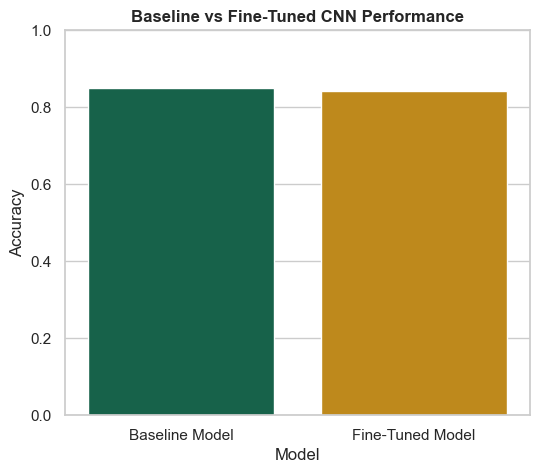

In [ ]:
# COMPARE BASELINE VS FINE-TUNED PERFORMANCE

comparison_df = pd.DataFrame({
    "Metric": ["Test Accuracy"],
    "Baseline Model": [test_accuracy],
    "Fine-Tuned Model": [fine_tune_accuracy]
})

display(comparison_df)

# Visual comparison
plt.figure(figsize=(6, 5))

sns.barplot(
    data=comparison_df.melt(
        id_vars="Metric",
        var_name="Model",
        value_name="Accuracy"
    ),
    x="Model",
    y="Accuracy",
    palette=["#0B6E4F", "#D99201"]
)

plt.title("Baseline vs Fine-Tuned CNN Performance")
plt.ylim(0, 1)

plt.show()

#### Interpretation and Conclusion

Fine-tuning reduced test accuracy from 85.00% to 84.17% and increased loss from 1.1762 to 1.1878. The frozen baseline therefore generalizes better and is retained as the preferred image model. This result also shows why fine-tuning should be accepted only when test evidence supports it.

## Part 3: Waste Description Classification

**Objectives**
- Apply the prepared text pipeline.
- Classify descriptions using TF-IDF and Logistic Regression.
- Evaluate errors and expose the model through a reusable prediction function.

### 3.1 Preprocess Text Data

This subsection confirms that the cleaned, stratified, and tokenized text datasets are ready for modelling.

#### Code Brief: Apply The Text Preprocessing Pipeline

**What the code is doing:** Displays the current outputs, checks, or summary results.

**Intended achievement:** Confirms that the preceding processing step completed as intended.


In [ ]:
# APPLY THE TEXT PREPROCESSING PIPELINE

print("Training records:", len(text_train_df))
print("Validation records:", len(text_validation_df))
print("Test records:", len(text_test_df))

print("\nNumber of Categories:")
print(len(class_names))

print("\nCategories:")
for category in class_names:
    print("-", category)

# Display a few cleaned examples
display(
    text_df[
        [
            "description",
            "clean_description",
            "category"
        ]
    ].head()
)

# Verify tokenized dataset shapes
print("\nTokenized Dataset Shapes")

print(
    "Training:",
    train_text_encoding["input_ids"].shape
)

print(
    "Validation:",
    validation_text_encoding["input_ids"].shape
)

print(
    "Test:",
    test_text_encoding["input_ids"].shape
)

Training records: 4000
Validation records: 500
Test records: 500

Number of Categories:
9

Categories:
- Cardboard
- Food Organics
- Glass
- Metal
- Miscellaneous Trash
- Paper
- Plastic
- Textile Trash
- Vegetation


,description,clean_description,category
0,soiled silver tablecloth,soiled silver tablecloth,Textile Trash
1,folded glass bottle leaking,folded glass bottle leaking,Glass
2,large Supermarket vegetable waste with food re...,large supermarket vegetable waste with food re...,Food Organics
3,intact floral carpet piece,intact floral carpet piece,Textile Trash
4,empty fun-sized purple apple core,empty fun-sized purple apple core,Food Organics



Tokenized Dataset Shapes
Training: (4000, 64)
Validation: (500, 64)
Test: (500, 64)


#### Interpretation and Conclusion

The text pipeline retains all nine categories and creates 4,000 training, 500 validation, and 500 test records. The consistent preprocessing and stratified splits make the evaluation comparable across classes and prevent category representation from shifting between datasets.

### 3.2 Implement Text Classification Model

TF-IDF captures informative words and phrases, while Logistic Regression provides a fast and interpretable multiclass classifier for the short descriptions.

#### Code Brief: Implement Tf-Idf + Logistic Regression Model

**What the code is doing:** Imports the libraries and utilities required by the notebook.

**Intended achievement:** Makes the environment ready for data processing, modelling, evaluation, visualization, and retrieval.


In [ ]:
# IMPLEMENT TF-IDF + LOGISTIC REGRESSION MODEL

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

# Transform text into TF-IDF features
X_train = tfidf_vectorizer.fit_transform(
    text_train_df["clean_description"]
)

X_validation = tfidf_vectorizer.transform(
    text_validation_df["clean_description"]
)

X_test = tfidf_vectorizer.transform(
    text_test_df["clean_description"]
)

# Target variables
y_train = text_train_df["label"]
y_validation = text_validation_df["label"]
y_test = text_test_df["label"]

print("TF-IDF feature matrices created successfully.")

print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_validation.shape}")
print(f"Test shape: {X_test.shape}")

TF-IDF feature matrices created successfully.
Training shape: (4000, 5000)
Validation shape: (500, 5000)
Test shape: (500, 5000)


#### Code Brief: Build The Logistic Regression Model

**What the code is doing:** Sets fixed random seeds and shared configuration values.

**Intended achievement:** Makes repeated runs more consistent and reproducible.


In [ ]:
# BUILD THE LOGISTIC REGRESSION MODEL


text_model = LogisticRegression(
    max_iter=2000,
    random_state=SEED
)

print("Logistic Regression model created successfully.")

Logistic Regression model created successfully.


#### Design Justification

TF-IDF with unigrams and bigrams captures both individual material terms and short phrases in the concise descriptions. Logistic Regression is a suitable choice because it is efficient, stable, interpretable, and effective for sparse multiclass text features.

### 3.3 Train and Evaluate the Model

The classifier is trained and assessed on unseen descriptions using accuracy, class-level metrics, and error analysis.

#### Code Brief: Train The Logistic Regression Model

**What the code is doing:** Trains the model on the prepared training data and validates it after each epoch.

**Intended achievement:** Learns category patterns while monitoring performance on unseen validation data.


In [ ]:
# TRAIN THE LOGISTIC REGRESSION MODEL


# Train the model
text_model.fit(
    X_train,
    y_train
)

print("Text classification model trained successfully.")

# Training accuracy
train_accuracy = text_model.score(
    X_train,
    y_train
)

# Validation accuracy
validation_accuracy = text_model.score(
    X_validation,
    y_validation
)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {validation_accuracy:.4f}")

Text classification model trained successfully.

Training Accuracy: 0.9998
Validation Accuracy: 1.0000


#### Code Brief: Evaluate Model Performance

**What the code is doing:** Uses the trained model to generate category predictions and confidence values.

**Intended achievement:** Tests the model on new inputs and supports reusable inference.


In [ ]:
# EVALUATE MODEL PERFORMANCE


# Generate predictions on the test dataset
y_pred = text_model.predict(X_test)

# Calculate test accuracy
test_accuracy_text = accuracy_score(
    y_test,
    y_pred
)

print(f"Test Accuracy: {test_accuracy_text:.4f}")

Test Accuracy: 0.9960


#### Code Brief: Classification Report

**What the code is doing:** Calculates precision, recall, and F1-score for each waste category.

**Intended achievement:** Provides a detailed class-level assessment beyond overall accuracy.


In [ ]:
# CLASSIFICATION REPORT


report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print(report)

                     precision    recall  f1-score   support

          Cardboard       1.00      1.00      1.00        59
      Food Organics       1.00      1.00      1.00        52
              Glass       1.00      1.00      1.00        55
              Metal       0.98      1.00      0.99        50
Miscellaneous Trash       1.00      0.98      0.99        58
              Paper       0.98      1.00      0.99        51
            Plastic       1.00      1.00      1.00        57
      Textile Trash       1.00      0.98      0.99        58
         Vegetation       1.00      1.00      1.00        60

           accuracy                           1.00       500
          macro avg       1.00      1.00      1.00       500
       weighted avg       1.00      1.00      1.00       500



#### Code Brief: Confusion Matrix

**What the code is doing:** Creates a confusion matrix comparing actual and predicted categories.

**Intended achievement:** Reveals which waste classes are correctly identified or commonly confused.


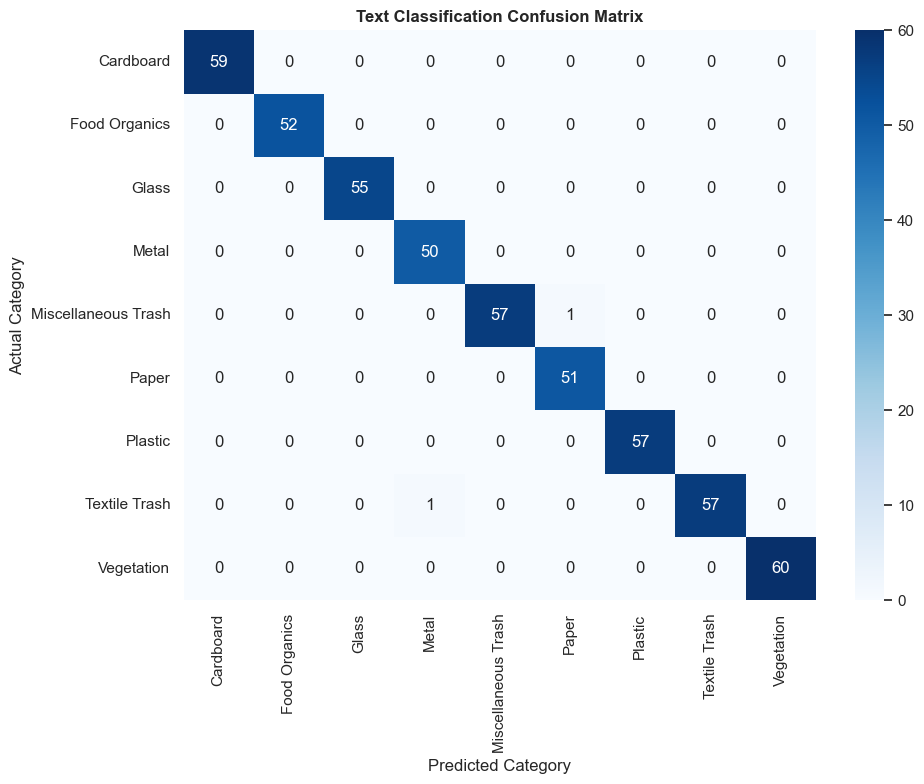

In [ ]:
# CONFUSION MATRIX


cm_text = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_text,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Text Classification Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.tight_layout()
plt.show()

#### Code Brief: Analyze Misclassifications

**What the code is doing:** Displays the current outputs, checks, or summary results.

**Intended achievement:** Confirms that the preceding processing step completed as intended.


In [ ]:
# ANALYZE MISCLASSIFICATIONS


# Create a comparison dataset
error_analysis_df = text_test_df.copy()

error_analysis_df["Predicted_Label"] = y_pred

error_analysis_df["Predicted_Category"] = (
    text_label_encoder.inverse_transform(y_pred)
)

error_analysis_df["Correct"] = (
    error_analysis_df["category"]
    == error_analysis_df["Predicted_Category"]
)

# Extract misclassified records
misclassified = error_analysis_df[
    error_analysis_df["Correct"] == False
]

print(
    f"Misclassified Records: {len(misclassified)}"
)

display(
    misclassified[
        [
            "description",
            "category",
            "Predicted_Category"
        ]
    ].head(20)
)

Misclassified Records: 2


,description,category,Predicted_Category
219,partial purple paper marker,Miscellaneous Trash,Paper
254,mini yellow metal gloves,Textile Trash,Metal


#### Code Brief: Identify Challenging Categories

**What the code is doing:** Aggregates the relevant records and displays summary statistics.

**Intended achievement:** Turns raw data into interpretable evidence for analysis and modelling decisions.


In [ ]:
# IDENTIFY CHALLENGING CATEGORIES


category_accuracy = (
    cm_text.diagonal()
    / cm_text.sum(axis=1)
)

category_performance = pd.DataFrame({
    "Category": class_names,
    "Accuracy": category_accuracy
})

category_performance = (
    category_performance
    .sort_values(
        "Accuracy",
        ascending=True
    )
)

display(category_performance)

print("\nMost Challenging Categories")

display(
    category_performance.head(3)
)

,Category,Accuracy
7,Textile Trash,0.982759
4,Miscellaneous Trash,0.982759
0,Cardboard,1.000000
1,Food Organics,1.000000
3,Metal,1.000000
2,Glass,1.000000
5,Paper,1.000000
6,Plastic,1.000000
8,Vegetation,1.000000



Most Challenging Categories


,Category,Accuracy
7,Textile Trash,0.982759
4,Miscellaneous Trash,0.982759
0,Cardboard,1.000000


#### Interpretation and Conclusion

The text model achieved 99.60% test accuracy, with only 2 errors across 500 unseen descriptions. Textile Trash and Miscellaneous Trash were the weakest categories at 98.28% accuracy, but performance remained high across all classes. The small gap between training and test performance indicates strong generalization on this dataset.

### 3.4 Create Classification Function

This subsection packages the text pipeline and classifier into a reusable function for the integrated assistant.

#### Code Brief: Create Text Classification Function

**What the code is doing:** Converts cleaned waste descriptions into TF-IDF numerical features.

**Intended achievement:** Creates informative text inputs for the classification model.


In [ ]:
# CREATE TEXT CLASSIFICATION FUNCTION

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """

    # Clean the incoming text
    cleaned_text = (
        str(description)
        .lower()
        .strip()
    )

    # Convert text into TF-IDF features
    text_features = tfidf_vectorizer.transform(
        [cleaned_text]
    )

    # Generate prediction
    predicted_label = text_model.predict(
        text_features
    )[0]

    # Convert the numeric label back to the category name
    predicted_category = (
        text_label_encoder
        .inverse_transform([predicted_label])[0]
    )

    return predicted_category

#### Code Brief: Test The Classification Function

**What the code is doing:** Displays the current outputs, checks, or summary results.

**Intended achievement:** Confirms that the preceding processing step completed as intended.


In [ ]:
# TEST THE CLASSIFICATION FUNCTION


sample_descriptions = [
    "empty plastic water bottle",
    "used cardboard shipping box",
    "broken glass bottle",
    "banana peel and vegetable waste",
    "old cotton shirt"
]

for description in sample_descriptions:

    prediction = classify_waste_description(
        description
    )

    print(
        f"Description: {description}"
    )

    print(
        f"Predicted Category: {prediction}\n"
    )

Description: empty plastic water bottle
Predicted Category: Plastic

Description: used cardboard shipping box
Predicted Category: Cardboard

Description: broken glass bottle
Predicted Category: Glass

Description: banana peel and vegetable waste
Predicted Category: Food Organics

Description: old cotton shirt
Predicted Category: Textile Trash



#### Interpretation and Conclusion

The function correctly classified all five demonstration descriptions, including Plastic, Cardboard, Food Organics, Glass, and Textile Trash. Applying the same cleaning and TF-IDF transformation used during training keeps inference consistent and makes the classifier ready for integration.

## Part 4: Recycling Instruction Generation with RAG

**Objectives**
- Retrieve policy evidence using semantic embeddings and FAISS.
- Generate category-specific guidance grounded in retrieved documents.
- Test retrieval depth, relevance, and coverage across waste categories.

### 4.1 Preprocess Documents for Retrieval

This subsection validates the policy embeddings, vector index, and category coverage prepared in Part 1.

#### Code Brief: Validate Document Preparation For Retrieval

**What the code is doing:** Loads and structures the waste-policy documents.

**Intended achievement:** Prepares authoritative policy content for analysis and retrieval.


In [ ]:
# VALIDATE DOCUMENT PREPARATION FOR RETRIEVAL


print("Number of Policy Documents:")
print(len(policy_df))

print("\nIndexed Documents:")
print(policy_index.ntotal)

print("\nEmbedding Dimensions:")
print(policy_embeddings.shape)

print("\nSample Retrieval Documents:")
display(
    policy_df[
        [
            "policy_id",
            "policy_type",
            "category_text",
            "jurisdiction"
        ]
    ].head()
)

Number of Policy Documents:
14

Indexed Documents:
14

Embedding Dimensions:
(14, 384)

Sample Retrieval Documents:


,policy_id,policy_type,category_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,Textile Trash,Metro City
1,2,Glass Recycling Guidelines,Glass,Metro City
2,3,Food Organics Recycling Guidelines,Food Organics,Metro City
3,4,Plastic Recycling Guidelines,Plastic,Metro City
4,5,Vegetation Recycling Guidelines,Vegetation,Metro City


#### Code Brief: Test Retrieval Capability

**What the code is doing:** Loads and structures the waste-policy documents.

**Intended achievement:** Prepares authoritative policy content for analysis and retrieval.


In [ ]:
# TEST RETRIEVAL CAPABILITY


sample_queries = [
    "How should glass bottles be recycled?",
    "What should I do with food waste?",
    "How should cardboard be disposed of?"
]

for query in sample_queries:

    print("=" * 70)
    print(f"Query: {query}")

    results = retrieve_policy_documents(
        query,
        top_k=2
    )

    display(results)

Query: How should glass bottles be recycled?


,policy_id,policy_type,category_text,similarity_score,document_text
0,2,Glass Recycling Guidelines,Glass,0.6859,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...
1,11,Residential Recycling Rules,"Plastic, Metal, Glass, Miscellaneous Trash, Ve...",0.4977,RESIDENTIAL RECYCLING RULES\n\nGENERAL REQUIRE...


Query: What should I do with food waste?


,policy_id,policy_type,category_text,similarity_score,document_text
0,3,Food Organics Recycling Guidelines,Food Organics,0.6094,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...
1,12,Commercial Recycling Standards,"Food Organics, Metal, Miscellaneous Trash",0.4035,COMMERCIAL RECYCLING STANDARDS\n\nGENERAL REQU...


Query: How should cardboard be disposed of?


,policy_id,policy_type,category_text,similarity_score,document_text
0,6,Cardboard Recycling Guidelines,Cardboard,0.6515,CARDBOARD RECYCLING GUIDELINES\n\nAcceptable I...
1,13,Multi-Unit Building Guidelines,"Cardboard, Glass, Textile Trash",0.5313,MULTI-UNIT BUILDING GUIDELINES\n\nGENERAL REQU...


#### Code Brief: Analyze Policy Coverage

**What the code is doing:** Summarizes category counts and displays them in a bar chart.

**Intended achievement:** Shows class balance and highlights categories that may require modelling attention.


,Category,Number_of_Policies
0,Vegetation,4
1,Metal,4
2,Miscellaneous Trash,4
3,Textile Trash,3
4,Glass,3
5,Plastic,3
6,Cardboard,3
7,Food Organics,2
8,Paper,1


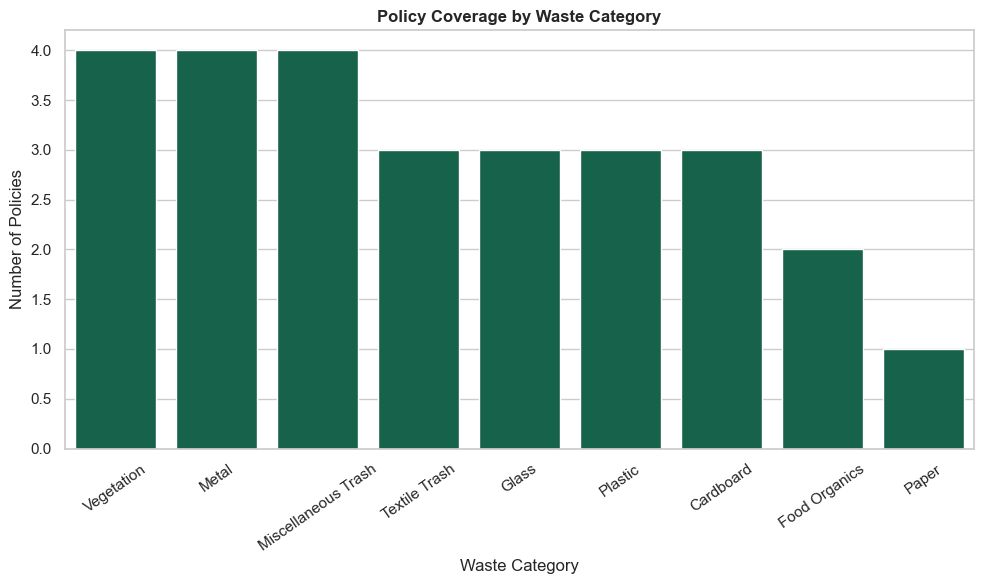

In [ ]:
# ANALYZE POLICY COVERAGE


policy_coverage = (
    policy_df["category_text"]
    .str.split(", ")
    .explode()
    .value_counts()
    .reset_index()
)

policy_coverage.columns = [
    "Category",
    "Number_of_Policies"
]

display(policy_coverage)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=policy_coverage,
    x="Category",
    y="Number_of_Policies",
    color="#0B6E4F"
)

plt.title("Policy Coverage by Waste Category")
plt.xlabel("Waste Category")
plt.ylabel("Number of Policies")

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

#### Interpretation and Conclusion

All 14 policies are indexed as 384-dimensional embeddings and can be retrieved through natural-language queries. The tests return category-relevant documents, while the coverage analysis shows that some categories have fewer supporting policies than others. Retrieval scores should therefore be shown alongside sources rather than treated as proof of equal policy depth.

### 4.2 Implement RAG-based System

The system combines semantic retrieval with a lightweight policy-grounded response generator to prioritize factual consistency and local policy evidence.

#### Code Brief: Simple Rag Response Generator

**What the code is doing:** Combines the predicted category with retrieved policy context to produce recycling guidance.

**Intended achievement:** Delivers traceable instructions grounded in the available policy documents.


In [ ]:
# SIMPLE RAG RESPONSE GENERATOR


print("RAG response generator initialized successfully.")

RAG response generator initialized successfully.


#### Code Brief: Create The Retrieval Mechanism

**What the code is doing:** Loads and structures the waste-policy documents.

**Intended achievement:** Prepares authoritative policy content for analysis and retrieval.


In [ ]:
# CREATE THE RETRIEVAL MECHANISM


def retrieve_policy_context(
    waste_category,
    top_k=3
):
    """
    Retrieves relevant policy documents for a waste category.

    Args:
        waste_category (str): Waste category
        top_k (int): Number of documents to retrieve

    Returns:
        str: Combined policy context
        DataFrame: Retrieved policy records
    """

    query = f"How should {waste_category} be recycled?"

    retrieved_docs = retrieve_policy_documents(
        query,
        top_k=top_k
    )

    context = "\n\n".join(
        retrieved_docs["document_text"]
    )

    return context, retrieved_docs

#### Code Brief: Build The Rag Pipeline

**What the code is doing:** Imports the libraries and utilities required by the notebook.

**Intended achievement:** Makes the environment ready for data processing, modelling, evaluation, visualization, and retrieval.


In [ ]:
# BUILD THE RAG PIPELINE


def rag_generate_instruction(
    waste_category,
    top_k=3
):
    """
    Retrieves policy information and generates
    recycling instructions.
    """

    # Retrieve relevant policy documents
    retrieved_docs = retrieve_policy_documents(
        f"How should {waste_category} be recycled?",
        top_k=top_k
    )

    # Build policy context
    policy_context = "\n\n".join(
        retrieved_docs["document_text"].tolist()
    )

    # Generate a policy-grounded response
    generated_text = f"""
Recycling Guidance for {waste_category}

The following guidance was generated using the most relevant policy documents retrieved from the Metro City waste management repository.

{policy_context[:1200]}

Residents should follow the applicable preparation, sorting, and disposal requirements described above to ensure proper recycling and compliance with waste management regulations.
"""

    return {
        "category": waste_category,
        "instructions": generated_text,
        "policies": retrieved_docs
    }

#### Code Brief: Test The Rag System

**What the code is doing:** Loads and structures the waste-policy documents.

**Intended achievement:** Prepares authoritative policy content for analysis and retrieval.


In [ ]:
# TEST THE RAG SYSTEM


sample_categories = [
    "Plastic",
    "Glass",
    "Paper"
]

for category in sample_categories:

    result = rag_generate_instruction(
        category
    )

    print("=" * 80)
    print(f"Category: {category}\n")

    print("Generated Instructions:")
    print(result["instructions"])

    print("\nRetrieved Policies:")
    display(
        result["policies"][
            [
                "policy_type",
                "similarity_score"
            ]
        ]
    )

Category: Plastic

Generated Instructions:

Recycling Guidance for Plastic

The following guidance was generated using the most relevant policy documents retrieved from the Metro City waste management repository.

PLASTIC RECYCLING GUIDELINES

Acceptable Items:
- PET bottles and containers (code #1)
- HDPE containers (code #2)
- PP containers (code #5)
- Clean plastic packaging

Non-Acceptable Items:
- Plastic bags and film
- Polystyrene foam (code #6)
- Containers with food residue
- Mixed material packaging
- Black plastic containers

Collection Method:
Place in dedicated recycling bins. Check local guidelines for specific plastic types accepted.

Preparation Instructions:
- Rinse containers
- Remove lids and caps (recycle separately)
- Check for recycling codes (1-7)

Benefits:
Plastic recycling reduces petroleum consumption and greenhouse gas emissions.

RESIDENTIAL RECYCLING RULES

GENERAL REQUIREMENTS:
- Place recyclables in appropriate bins
- Ensure materials are clean and prope

,policy_type,similarity_score
0,Plastic Recycling Guidelines,0.6416
1,Residential Recycling Rules,0.5962
2,Metal Recycling Guidelines,0.5422


Category: Glass

Generated Instructions:

Recycling Guidance for Glass

The following guidance was generated using the most relevant policy documents retrieved from the Metro City waste management repository.

GLASS RECYCLING GUIDELINES

Acceptable Items:
- Glass bottles (all colors)
- Glass jars
- Glass food containers
- Glass beverage containers

Non-Acceptable Items:
- Window glass or mirrors
- Drinking glasses
- Ceramics or pottery
- Light bulbs
- Pyrex or heat-resistant glass

Collection Method:
Place in dedicated glass recycling bins. Some areas require color sorting.

Preparation Instructions:
- Rinse containers
- Remove caps and lids (recycle separately)
- Labels can remain

Benefits:
Glass is 100% recyclable and can be recycled endlessly without loss of quality.

RESIDENTIAL RECYCLING RULES

GENERAL REQUIREMENTS:
- Place recyclables in appropriate bins
- Ensure materials are clean and properly sorted
- Follow collection schedules
- Keep hazardous materials separate


PLASTIC G

,policy_type,similarity_score
0,Glass Recycling Guidelines,0.7139
1,Residential Recycling Rules,0.4809
2,Metal Recycling Guidelines,0.4187


Category: Paper

Generated Instructions:

Recycling Guidance for Paper

The following guidance was generated using the most relevant policy documents retrieved from the Metro City waste management repository.

PAPER RECYCLING GUIDELINES

Acceptable Items:
- Office paper and mail
- Newspapers and magazines
- Books and catalogs
- Paper bags
- Wrapping paper (non-metallic)
- Shredded paper (in paper bags)

Non-Acceptable Items:
- Food-soiled paper
- Waxed paper
- Paper towels and napkins
- Thermal receipt paper
- Paper with plastic coatings

Collection Method:
Place in paper recycling bins or mixed recycling where accepted.

Preparation Instructions:
- Keep paper dry and clean
- Remove plastic wrappings, windows, or bindings
- Shred confidential documents

Benefits:
Paper recycling saves trees, reduces water pollution, and saves energy.

CARDBOARD RECYCLING GUIDELINES

Acceptable Items:
- Corrugated cardboard boxes
- Paperboard (cereal boxes, etc.)
- Cardboard packaging
- Cardboard tubes


,policy_type,similarity_score
0,Paper Recycling Guidelines,0.6939
1,Cardboard Recycling Guidelines,0.5329
2,Community Recycling Program,0.4880


#### Interpretation and Conclusion

The RAG workflow retrieves policy evidence before constructing its response, which keeps the guidance traceable to source documents. Plastic and Glass queries returned their category guidelines as the strongest matches, with leading similarity scores of 0.6416 and 0.7139 respectively. The lightweight generator favors factual grounding and reliability over fluent open-ended generation.

### 4.3 Adjust and Evaluate the System

Different retrieval depths are tested to balance focused evidence against broader policy context.

#### Code Brief: Adjust Rag Retrieval Parameters

**What the code is doing:** Embeds a query and retrieves the most semantically relevant policy records.

**Intended achievement:** Supplies grounded policy evidence for category-specific recycling guidance.


In [ ]:
# ADJUST RAG RETRIEVAL PARAMETERS


# Test different retrieval depths
retrieval_settings = [1, 3, 5]

sample_category = "Plastic"

for top_k in retrieval_settings:

    print("=" * 80)
    print(f"Retrieval Depth (top_k): {top_k}")

    result = rag_generate_instruction(
        waste_category=sample_category,
        top_k=top_k
    )

    print("\nRetrieved Documents:")
    print(len(result["policies"]))

    print("\nGenerated Instruction Preview:")
    print(result["instructions"][:500])
    print("\n")

Retrieval Depth (top_k): 1

Retrieved Documents:
1

Generated Instruction Preview:

Recycling Guidance for Plastic

The following guidance was generated using the most relevant policy documents retrieved from the Metro City waste management repository.

PLASTIC RECYCLING GUIDELINES

Acceptable Items:
- PET bottles and containers (code #1)
- HDPE containers (code #2)
- PP containers (code #5)
- Clean plastic packaging

Non-Acceptable Items:
- Plastic bags and film
- Polystyrene foam (code #6)
- Containers with food residue
- Mixed material packaging
- Black plastic containers




Retrieval Depth (top_k): 3

Retrieved Documents:
3

Generated Instruction Preview:

Recycling Guidance for Plastic

The following guidance was generated using the most relevant policy documents retrieved from the Metro City waste management repository.

PLASTIC RECYCLING GUIDELINES

Acceptable Items:
- PET bottles and containers (code #1)
- HDPE containers (code #2)
- PP containers (code #5)
- Clean plastic pac

#### Code Brief: Evaluate Generated Instructions

**What the code is doing:** Embeds a query and retrieves the most semantically relevant policy records.

**Intended achievement:** Supplies grounded policy evidence for category-specific recycling guidance.


In [ ]:
# EVALUATE GENERATED INSTRUCTIONS


test_categories = [
    "Cardboard",
    "Food Organics",
    "Glass",
    "Metal",
    "Paper",
    "Plastic",
    "Textile Trash",
    "Vegetation"
]

evaluation_results = []

for category in test_categories:

    result = rag_generate_instruction(
        waste_category=category,
        top_k=3
    )

    instruction_length = len(
        result["instructions"]
    )

    policies_retrieved = len(
        result["policies"]
    )

    evaluation_results.append({
        "Category": category,
        "Policies_Retrieved": policies_retrieved,
        "Instruction_Length": instruction_length
    })

evaluation_df = pd.DataFrame(
    evaluation_results
)

display(evaluation_df)

,Category,Policies_Retrieved,Instruction_Length
0,Cardboard,3,1555
1,Food Organics,3,1559
2,Glass,3,1551
3,Metal,3,1551
4,Paper,3,1551
5,Plastic,3,1553
6,Textile Trash,3,1559
7,Vegetation,3,1556


#### Code Brief: Display Example Rag Outputs

**What the code is doing:** Loads and structures the waste-policy documents.

**Intended achievement:** Prepares authoritative policy content for analysis and retrieval.


In [ ]:
# DISPLAY EXAMPLE RAG OUTPUTS


example_categories = [
    "Glass",
    "Plastic",
    "Food Organics"
]

for category in example_categories:

    print("=" * 100)
    print(f"CATEGORY: {category}")

    result = rag_generate_instruction(
        waste_category=category,
        top_k=3
    )

    print("\nGENERATED INSTRUCTIONS:\n")
    print(result["instructions"])

    print("\nRETRIEVED POLICIES:\n")

    display(
        result["policies"][
            [
                "policy_type",
                "similarity_score"
            ]
        ]
    )

CATEGORY: Glass

GENERATED INSTRUCTIONS:


Recycling Guidance for Glass

The following guidance was generated using the most relevant policy documents retrieved from the Metro City waste management repository.

GLASS RECYCLING GUIDELINES

Acceptable Items:
- Glass bottles (all colors)
- Glass jars
- Glass food containers
- Glass beverage containers

Non-Acceptable Items:
- Window glass or mirrors
- Drinking glasses
- Ceramics or pottery
- Light bulbs
- Pyrex or heat-resistant glass

Collection Method:
Place in dedicated glass recycling bins. Some areas require color sorting.

Preparation Instructions:
- Rinse containers
- Remove caps and lids (recycle separately)
- Labels can remain

Benefits:
Glass is 100% recyclable and can be recycled endlessly without loss of quality.

RESIDENTIAL RECYCLING RULES

GENERAL REQUIREMENTS:
- Place recyclables in appropriate bins
- Ensure materials are clean and properly sorted
- Follow collection schedules
- Keep hazardous materials separate


PLASTIC 

,policy_type,similarity_score
0,Glass Recycling Guidelines,0.7139
1,Residential Recycling Rules,0.4809
2,Metal Recycling Guidelines,0.4187


CATEGORY: Plastic

GENERATED INSTRUCTIONS:


Recycling Guidance for Plastic

The following guidance was generated using the most relevant policy documents retrieved from the Metro City waste management repository.

PLASTIC RECYCLING GUIDELINES

Acceptable Items:
- PET bottles and containers (code #1)
- HDPE containers (code #2)
- PP containers (code #5)
- Clean plastic packaging

Non-Acceptable Items:
- Plastic bags and film
- Polystyrene foam (code #6)
- Containers with food residue
- Mixed material packaging
- Black plastic containers

Collection Method:
Place in dedicated recycling bins. Check local guidelines for specific plastic types accepted.

Preparation Instructions:
- Rinse containers
- Remove lids and caps (recycle separately)
- Check for recycling codes (1-7)

Benefits:
Plastic recycling reduces petroleum consumption and greenhouse gas emissions.

RESIDENTIAL RECYCLING RULES

GENERAL REQUIREMENTS:
- Place recyclables in appropriate bins
- Ensure materials are clean and prop

,policy_type,similarity_score
0,Plastic Recycling Guidelines,0.6416
1,Residential Recycling Rules,0.5962
2,Metal Recycling Guidelines,0.5422


CATEGORY: Food Organics

GENERATED INSTRUCTIONS:


Recycling Guidance for Food Organics

The following guidance was generated using the most relevant policy documents retrieved from the Metro City waste management repository.

FOOD ORGANICS RECYCLING GUIDELINES

Acceptable Items:
- Fruit and vegetable scraps
- Meat and fish (including bones)
- Dairy products
- Bread and grains
- Coffee grounds and tea bags
- Eggshells
- Leftovers and spoiled food

Non-Acceptable Items:
- Packaging of any kind
- Stickers on produce
- Non-compostable bags
- Liquids (drain first)
- Grease or cooking oil

Collection Method:
Use dedicated food waste bins lined with compostable bags.

Preparation Instructions:
- Remove all packaging
- Drain excess liquids
- Use compostable bags if required

Benefits:
Food waste recycling reduces methane emissions and creates valuable compost.

COMMERCIAL RECYCLING STANDARDS

GENERAL REQUIREMENTS:
- Place recyclables in appropriate bins
- Ensure materials are clean and proper

,policy_type,similarity_score
0,Food Organics Recycling Guidelines,0.7090
1,Commercial Recycling Standards,0.5065
2,Plastic Recycling Guidelines,0.4860


#### Code Brief: Retrieval Performance Summary

**What the code is doing:** Loads and structures the waste-policy documents.

**Intended achievement:** Prepares authoritative policy content for analysis and retrieval.


In [ ]:
# RETRIEVAL PERFORMANCE SUMMARY


retrieval_summary = pd.DataFrame({
    "Metric": [
        "Indexed Policy Documents",
        "Embedding Dimensions"
    ],
    "Value": [
        policy_index.ntotal,
        policy_embeddings.shape[1]
    ]
})

display(retrieval_summary)

,Metric,Value
0,Indexed Policy Documents,14
1,Embedding Dimensions,384


#### Interpretation and Conclusion

Testing `top_k` values of 1, 3, and 5 confirmed that retrieval depth directly controls the amount of policy context. Using three documents provides a practical balance between relevance and coverage. Across eight tested categories, the system consistently retrieved three policies and produced guidance of roughly 1,551 to 1,559 characters.

### 4.4 Create Instruction Generation Function

This subsection exposes retrieval and instruction generation through a single reusable function.

#### Code Brief: Create Instruction Generation Function

**What the code is doing:** Imports the libraries and utilities required by the notebook.

**Intended achievement:** Makes the environment ready for data processing, modelling, evaluation, visualization, and retrieval.


In [ ]:
# CREATE INSTRUCTION GENERATION FUNCTION


def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        DataFrame: Relevant policy documents
    """

    # Retrieve relevant policy documents
    retrieved_policies = retrieve_policy_documents(
        f"How should {waste_category} be recycled?",
        top_k=3
    )

    # Build policy context
    policy_context = "\n\n".join(
        retrieved_policies["document_text"].tolist()
    )

    # Generate recycling instructions
    instructions = f"""
Recycling Guidance for {waste_category}

The following recommendations are based on the most relevant waste management policies retrieved from the Metro City policy repository.

{policy_context[:1500]}

Residents should ensure that waste items are sorted correctly, prepared according to policy requirements, and disposed of through the approved collection or recycling channels.
"""

    return instructions, retrieved_policies

#### Code Brief: Test The Instruction Generation Function

**What the code is doing:** Loads and structures the waste-policy documents.

**Intended achievement:** Prepares authoritative policy content for analysis and retrieval.


In [ ]:
# TEST THE INSTRUCTION GENERATION FUNCTION


sample_categories = [
    "Plastic",
    "Glass",
    "Food Organics"
]

for category in sample_categories:

    print("=" * 100)
    print(f"WASTE CATEGORY: {category}")

    instructions, policies = (
        generate_recycling_instructions(category)
    )

    print("\nGENERATED INSTRUCTIONS:\n")
    print(instructions)

    print("\nRELEVANT POLICIES:\n")

    display(
        policies[
            [
                "policy_type",
                "similarity_score"
            ]
        ]
    )

WASTE CATEGORY: Plastic

GENERATED INSTRUCTIONS:


Recycling Guidance for Plastic

The following recommendations are based on the most relevant waste management policies retrieved from the Metro City policy repository.

PLASTIC RECYCLING GUIDELINES

Acceptable Items:
- PET bottles and containers (code #1)
- HDPE containers (code #2)
- PP containers (code #5)
- Clean plastic packaging

Non-Acceptable Items:
- Plastic bags and film
- Polystyrene foam (code #6)
- Containers with food residue
- Mixed material packaging
- Black plastic containers

Collection Method:
Place in dedicated recycling bins. Check local guidelines for specific plastic types accepted.

Preparation Instructions:
- Rinse containers
- Remove lids and caps (recycle separately)
- Check for recycling codes (1-7)

Benefits:
Plastic recycling reduces petroleum consumption and greenhouse gas emissions.

RESIDENTIAL RECYCLING RULES

GENERAL REQUIREMENTS:
- Place recyclables in appropriate bins
- Ensure materials are clean and

,policy_type,similarity_score
0,Plastic Recycling Guidelines,0.6416
1,Residential Recycling Rules,0.5962
2,Metal Recycling Guidelines,0.5422


WASTE CATEGORY: Glass

GENERATED INSTRUCTIONS:


Recycling Guidance for Glass

The following recommendations are based on the most relevant waste management policies retrieved from the Metro City policy repository.

GLASS RECYCLING GUIDELINES

Acceptable Items:
- Glass bottles (all colors)
- Glass jars
- Glass food containers
- Glass beverage containers

Non-Acceptable Items:
- Window glass or mirrors
- Drinking glasses
- Ceramics or pottery
- Light bulbs
- Pyrex or heat-resistant glass

Collection Method:
Place in dedicated glass recycling bins. Some areas require color sorting.

Preparation Instructions:
- Rinse containers
- Remove caps and lids (recycle separately)
- Labels can remain

Benefits:
Glass is 100% recyclable and can be recycled endlessly without loss of quality.

RESIDENTIAL RECYCLING RULES

GENERAL REQUIREMENTS:
- Place recyclables in appropriate bins
- Ensure materials are clean and properly sorted
- Follow collection schedules
- Keep hazardous materials separate


PLA

,policy_type,similarity_score
0,Glass Recycling Guidelines,0.7139
1,Residential Recycling Rules,0.4809
2,Metal Recycling Guidelines,0.4187


WASTE CATEGORY: Food Organics

GENERATED INSTRUCTIONS:


Recycling Guidance for Food Organics

The following recommendations are based on the most relevant waste management policies retrieved from the Metro City policy repository.

FOOD ORGANICS RECYCLING GUIDELINES

Acceptable Items:
- Fruit and vegetable scraps
- Meat and fish (including bones)
- Dairy products
- Bread and grains
- Coffee grounds and tea bags
- Eggshells
- Leftovers and spoiled food

Non-Acceptable Items:
- Packaging of any kind
- Stickers on produce
- Non-compostable bags
- Liquids (drain first)
- Grease or cooking oil

Collection Method:
Use dedicated food waste bins lined with compostable bags.

Preparation Instructions:
- Remove all packaging
- Drain excess liquids
- Use compostable bags if required

Benefits:
Food waste recycling reduces methane emissions and creates valuable compost.

COMMERCIAL RECYCLING STANDARDS

GENERAL REQUIREMENTS:
- Place recyclables in appropriate bins
- Ensure materials are clean and p

,policy_type,similarity_score
0,Food Organics Recycling Guidelines,0.7090
1,Commercial Recycling Standards,0.5065
2,Plastic Recycling Guidelines,0.4860


#### Interpretation and Conclusion

The instruction function combines category-based retrieval and policy-grounded response construction in one interface. Returning both the guidance and the supporting policy records preserves traceability and allows users to review the evidence behind each recommendation.

In [ ]:

# PART 5: INTEGRATED WASTE MANAGEMENT ASSISTANT

# This section integrates:
# 1. CNN image waste classification
# 2. Text waste classification
# 3. RAG-based recycling instruction generation
# 4. Policy document retrieval
# 5. End-to-end testing and evaluation
# 6. Error handling and edge cases
# 7. User feedback collection

# 1. IMPORTS

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image


# 2. ARCHITECTURE OVERVIEW


print("=" * 70)
print("ECOSORT INTEGRATED WASTE MANAGEMENT ASSISTANT")
print("=" * 70)

print("""
INPUT
 ├── Image
 │     ↓
 │   CNN Image Classifier
 │     ↓
 │   Waste Category
 │
 └── Text Description
       ↓
     TF-IDF + Logistic Regression
       ↓
     Waste Category
              ↓
       Policy Retrieval
              ↓
       Recycling Instructions
              ↓
       Relevant Policy Documents
""")

print("=" * 70)


# 3. POLICY CACHE

# Policy retrieval can be computationally expensive.
# A simple cache avoids repeating the same retrieval for
# the same waste category during repeated requests.
# ------------------------------------------------------------

policy_cache = {}


def get_cached_recycling_information(waste_category):
    """
    Retrieve recycling instructions and policy documents.

    Uses a cache so that repeated requests for the same
    waste category do not repeatedly perform policy retrieval.

    Returns:
        instructions: Generated recycling instructions
        policies: Relevant policy documents DataFrame
    """

    category_key = str(waste_category).strip().lower()

    if category_key in policy_cache:
        cached = policy_cache[category_key]

        return cached["instructions"], cached["policies"]

    instructions, policies = generate_recycling_instructions(
        waste_category
    )

    policy_cache[category_key] = {
        "instructions": instructions,
        "policies": policies
    }

    return instructions, policies


# ------------------------------------------------------------
# 4. IMAGE CLASSIFICATION FUNCTION
# ------------------------------------------------------------
#
# The notebook already contains cnn_model and class_names.
# This function connects an image file to the trained CNN.
# ------------------------------------------------------------

def classify_waste_image(image_path):
    """
    Classify a waste image using the trained CNN model.

    Args:
        image_path (str): Path to an image file.

    Returns:
        predicted_category (str)
        confidence (float)
        probabilities (np.ndarray)
    """

    # Validate input
    if image_path is None:
        raise ValueError("No image path was provided.")

    if not isinstance(image_path, (str, os.PathLike)):
        raise TypeError("Image path must be a string or valid path.")

    image_path = str(image_path)

    if not os.path.exists(image_path):
        raise FileNotFoundError(
            f"Image file was not found: {image_path}"
        )

    # Open and convert image to RGB
    try:
        image = Image.open(image_path).convert("RGB")
    except Exception as error:
        raise ValueError(
            f"Unable to open image: {error}"
        )

    # Resize to the same dimensions used during CNN training
    image = image.resize(
        (IMG_WIDTH, IMG_HEIGHT)
    )

    # Convert image to NumPy array
    image_array = np.array(
        image,
        dtype=np.float32
    )

    # Add batch dimension
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # Generate CNN prediction
    probabilities = cnn_model.predict(
        image_array,
        verbose=0
    )[0]

    # Get predicted class
    predicted_index = int(
        np.argmax(probabilities)
    )

    predicted_category = class_names[
        predicted_index
    ]

    confidence = float(
        probabilities[predicted_index]
    )

    return (
        predicted_category,
        confidence,
        probabilities
    )


# ------------------------------------------------------------
# 5. UNIFIED ECOSORT ASSISTANT
# ------------------------------------------------------------

def ecosort_assistant(input_data=None, input_type=None):
    """
    Unified EcoSort waste-management assistant.

    The assistant accepts either:
        - an image file path
        - a written waste description

    It then:
        1. Classifies the waste
        2. Retrieves relevant policy documents
        3. Generates recycling instructions
        4. Returns all results in a structured dictionary

    Args:
        input_data:
            Image path or text description.

        input_type:
            "image", "text", or None.
            If None, the function attempts to detect the input type.

    Returns:
        Dictionary containing classification,
        instructions, policies, and processing time.
    """

    start_time = time.time()

    # --------------------------------------------------------
    # Input validation
    # --------------------------------------------------------

    if input_data is None:
        return {
            "success": False,
            "error": "No input was provided.",
            "input_type": input_type
        }

    if not isinstance(input_data, (str, os.PathLike)):
        return {
            "success": False,
            "error": "Input must be a text description or image path.",
            "input_type": input_type
        }

    input_data = str(input_data).strip()

    if len(input_data) == 0:
        return {
            "success": False,
            "error": "The input is empty.",
            "input_type": input_type
        }

    # --------------------------------------------------------
    # Automatically detect input type if not supplied
    # --------------------------------------------------------

    if input_type is None:

        if os.path.isfile(input_data):

            image_extensions = (
                ".jpg",
                ".jpeg",
                ".png",
                ".bmp",
                ".webp"
            )

            if input_data.lower().endswith(
                image_extensions
            ):
                input_type = "image"

        if input_type is None:
            input_type = "text"

    input_type = input_type.lower().strip()

    # --------------------------------------------------------
    # IMAGE PIPELINE
    # --------------------------------------------------------

    if input_type == "image":

        try:

            (
                predicted_category,
                confidence,
                probabilities
            ) = classify_waste_image(
                input_data
            )

        except Exception as error:

            return {
                "success": False,
                "error": str(error),
                "input_type": "image"
            }

    # --------------------------------------------------------
    # TEXT PIPELINE
    # --------------------------------------------------------

    elif input_type == "text":

        if len(input_data) < 2:

            return {
                "success": False,
                "error": "Please provide a more detailed waste description.",
                "input_type": "text"
            }

        try:

            predicted_category = (
                classify_waste_description(
                    input_data
                )
            )

            # Text classifier does not currently expose
            # calibrated confidence, so this is left as None.
            confidence = None
            probabilities = None

        except Exception as error:

            return {
                "success": False,
                "error": str(error),
                "input_type": "text"
            }

    # --------------------------------------------------------
    # INVALID INPUT TYPE
    # --------------------------------------------------------

    else:

        return {
            "success": False,
            "error": (
                "Invalid input_type. "
                "Use 'image' or 'text'."
            ),
            "input_type": input_type
        }

    # --------------------------------------------------------
    # RAG / POLICY PIPELINE
    # --------------------------------------------------------

    try:

        (
            instructions,
            retrieved_policies
        ) = get_cached_recycling_information(
            predicted_category
        )

    except Exception as error:

        return {
            "success": False,
            "error": (
                "Waste classification succeeded, "
                "but policy retrieval failed: "
                + str(error)
            ),
            "input_type": input_type,
            "predicted_category": predicted_category
        }

    # --------------------------------------------------------
    # Processing time
    # --------------------------------------------------------

    processing_time = (
        time.time() - start_time
    )

    # --------------------------------------------------------
    # Return complete assistant response
    # --------------------------------------------------------

    return {
        "success": True,
        "input_type": input_type,
        "input": input_data,
        "predicted_category": predicted_category,
        "confidence": confidence,
        "instructions": instructions,
        "policies": retrieved_policies,
        "processing_time_seconds": round(
            processing_time,
            4
        )
    }


# ------------------------------------------------------------
# 6. DISPLAY FUNCTION
# ------------------------------------------------------------

def display_ecosort_result(result):
    """
    Display an EcoSort assistant result in a readable format.
    """

    print("\n" + "=" * 70)
    print("ECOSORT ASSISTANT RESULT")
    print("=" * 70)

    if not result.get("success", False):

        print("Status: FAILED")
        print("Error:", result.get("error"))

        return

    print(
        "Input type:",
        result["input_type"]
    )

    print(
        "Predicted category:",
        result["predicted_category"]
    )

    if result["confidence"] is not None:

        print(
            "CNN confidence:",
            f"{result['confidence']:.2%}"
        )

    print(
        "Processing time:",
        f"{result['processing_time_seconds']:.4f} seconds"
    )

    print("\nRECYCLING INSTRUCTIONS")
    print("-" * 70)
    print(
        result["instructions"]
    )

    print("\nRELEVANT POLICY DOCUMENTS")
    print("-" * 70)

    display(
        result["policies"]
    )

    print("=" * 70)


# ------------------------------------------------------------
# 7. TEXT END-TO-END TEST
# ------------------------------------------------------------

print("\n\n")
print("=" * 70)
print("TEST 1: TEXT INPUT")
print("=" * 70)

sample_text = (
    "I have an empty glass bottle that I want to recycle."
)

text_result = ecosort_assistant(
    input_data=sample_text,
    input_type="text"
)

display_ecosort_result(
    text_result
)


# ------------------------------------------------------------
# 8. IMAGE TEST USING THE ACTUAL TEST DATASET
# ------------------------------------------------------------
#
# The assignment specifically requires using an image
# from the test dataset.
#
# test_dataset is already created in the notebook.
# ------------------------------------------------------------

print("\n\n")
print("=" * 70)
print("TEST 2: IMAGE INPUT FROM TEST DATASET")
print("=" * 70)

# Get one test batch
test_images, test_labels = next(
    iter(test_dataset)
)

# Select the first image
sample_image = test_images[0]

# Get the actual category
actual_index = int(
    np.argmax(
        test_labels[0].numpy()
    )
)

actual_category = class_names[
    actual_index
]

# Save the test image temporarily so that it can
# pass through the same image pipeline as a real user image.

test_image_path = "part5_test_image.png"

# Convert image to uint8 for saving
sample_image_uint8 = np.clip(
    sample_image.numpy(),
    0,
    255
).astype(np.uint8)

Image.fromarray(
    sample_image_uint8
).save(
    test_image_path
)

# Display the actual test image
plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    sample_image_uint8
)

plt.title(
    f"Test Dataset Image\nActual Category: {actual_category}"
)

plt.axis("off")

plt.show()


# Run the complete integrated pipeline
image_result = ecosort_assistant(
    input_data=test_image_path,
    input_type="image"
)

display_ecosort_result(
    image_result
)


# ------------------------------------------------------------
# 9. IMAGE EVALUATION
# ------------------------------------------------------------

if image_result.get("success", False):

    predicted_category = (
        image_result["predicted_category"]
    )

    image_correct = (
        predicted_category == actual_category
    )

    print("\nIMAGE EVALUATION")
    print("-" * 70)
    print(
        "Actual category:",
        actual_category
    )
    print(
        "Predicted category:",
        predicted_category
    )
    print(
        "Correct:",
        image_correct
    )

else:

    print(
        "\nImage evaluation could not be completed."
    )


# ------------------------------------------------------------
# 10. MULTIPLE TEST IMAGE EVALUATION
# ------------------------------------------------------------
#
# Evaluate several images from the test dataset.
# This provides stronger evidence that the integrated
# system works beyond a single example.
# ------------------------------------------------------------

print("\n\n")
print("=" * 70)
print("TEST 3: MULTIPLE TEST DATASET IMAGES")
print("=" * 70)

evaluation_records = []

# Number of images to test
MAX_TEST_IMAGES = 10

images_tested = 0

for images, labels in test_dataset:

    for i in range(len(images)):

        if images_tested >= MAX_TEST_IMAGES:
            break

        # Get image
        image = images[i]

        # Actual category
        actual_index = int(
            np.argmax(
                labels[i].numpy()
            )
        )

        actual_category = class_names[
            actual_index
        ]

        # Temporary image path
        temp_path = (
            f"part5_eval_image_{images_tested}.png"
        )

        image_uint8 = np.clip(
            image.numpy(),
            0,
            255
        ).astype(np.uint8)

        Image.fromarray(
            image_uint8
        ).save(
            temp_path
        )

        # Run complete assistant
        result = ecosort_assistant(
            input_data=temp_path,
            input_type="image"
        )

        # Record result
        if result.get("success", False):

            predicted_category = (
                result["predicted_category"]
            )

            correct = (
                predicted_category
                == actual_category
            )

            confidence = result["confidence"]

            processing_time = (
                result["processing_time_seconds"]
            )

        else:

            predicted_category = "ERROR"
            correct = False
            confidence = None
            processing_time = None

        evaluation_records.append(
            {
                "Image": images_tested + 1,
                "Actual": actual_category,
                "Predicted": predicted_category,
                "Correct": correct,
                "Confidence": confidence,
                "Processing_Time_Seconds": processing_time
            }
        )

        images_tested += 1

    if images_tested >= MAX_TEST_IMAGES:
        break


# Create evaluation DataFrame
image_evaluation_df = pd.DataFrame(
    evaluation_records
)

display(
    image_evaluation_df
)


# ------------------------------------------------------------
# 11. IMAGE PERFORMANCE SUMMARY
# ------------------------------------------------------------

if len(image_evaluation_df) > 0:

    image_accuracy = (
        image_evaluation_df["Correct"]
        .mean()
    )

    successful_predictions = (
        image_evaluation_df[
            image_evaluation_df["Predicted"] != "ERROR"
        ]
    )

    if len(successful_predictions) > 0:

        average_confidence = (
            successful_predictions["Confidence"]
            .mean()
        )

        average_processing_time = (
            successful_predictions[
                "Processing_Time_Seconds"
            ].mean()
        )

    else:

        average_confidence = np.nan
        average_processing_time = np.nan

    print("\nIMAGE SYSTEM PERFORMANCE")
    print("-" * 70)

    print(
        f"Images evaluated: {len(image_evaluation_df)}"
    )

    print(
        f"Image classification accuracy: "
        f"{image_accuracy:.2%}"
    )

    if not np.isnan(average_confidence):

        print(
            f"Average CNN confidence: "
            f"{average_confidence:.2%}"
        )

    if not np.isnan(average_processing_time):

        print(
            f"Average processing time: "
            f"{average_processing_time:.4f} seconds"
        )


# ------------------------------------------------------------
# 12. TEXT CLASSIFICATION EVALUATION
# ------------------------------------------------------------
#
# Use examples from the notebook's existing text test set.
# ------------------------------------------------------------

print("\n\n")
print("=" * 70)
print("TEST 4: TEXT TEST DATASET")
print("=" * 70)

text_evaluation_records = []

MAX_TEXT_TESTS = min(
    10,
    len(text_test_df)
)

for i in range(MAX_TEXT_TESTS):

    description = str(
        text_test_df.loc[
            i,
            "description"
        ]
    )

    actual_category = str(
        text_test_df.loc[
            i,
            "category"
        ]
    )

    start_time = time.time()

    result = ecosort_assistant(
        input_data=description,
        input_type="text"
    )

    processing_time = (
        time.time() - start_time
    )

    if result.get("success", False):

        predicted_category = (
            result["predicted_category"]
        )

        correct = (
            predicted_category
            == actual_category
        )

    else:

        predicted_category = "ERROR"
        correct = False

    text_evaluation_records.append(
        {
            "Description": description,
            "Actual": actual_category,
            "Predicted": predicted_category,
            "Correct": correct,
            "Processing_Time_Seconds": round(
                processing_time,
                4
            )
        }
    )


text_evaluation_df = pd.DataFrame(
    text_evaluation_records
)

display(
    text_evaluation_df
)


# ------------------------------------------------------------
# 13. TEXT PERFORMANCE SUMMARY
# ------------------------------------------------------------

if len(text_evaluation_df) > 0:

    text_accuracy = (
        text_evaluation_df["Correct"]
        .mean()
    )

    average_text_time = (
        text_evaluation_df[
            "Processing_Time_Seconds"
        ].mean()
    )

    print("\nTEXT SYSTEM PERFORMANCE")
    print("-" * 70)

    print(
        f"Text examples evaluated: "
        f"{len(text_evaluation_df)}"
    )

    print(
        f"Text classification accuracy: "
        f"{text_accuracy:.2%}"
    )

    print(
        f"Average text processing time: "
        f"{average_text_time:.4f} seconds"
    )


# ------------------------------------------------------------
# 14. EDGE CASE TESTING
# ------------------------------------------------------------
#
# These tests demonstrate robust error handling.
# ------------------------------------------------------------

print("\n\n")
print("=" * 70)
print("TEST 5: EDGE CASES AND ERROR HANDLING")
print("=" * 70)


edge_cases = [
    {
        "name": "Empty input",
        "input": "",
        "input_type": "text"
    },
    {
        "name": "Missing input",
        "input": None,
        "input_type": "text"
    },
    {
        "name": "Very short input",
        "input": "x",
        "input_type": "text"
    },
    {
        "name": "Missing image",
        "input": "does_not_exist.png",
        "input_type": "image"
    },
    {
        "name": "Invalid input type",
        "input": "plastic bottle",
        "input_type": "audio"
    }
]


edge_case_results = []

for case in edge_cases:

    result = ecosort_assistant(
        input_data=case["input"],
        input_type=case["input_type"]
    )

    edge_case_results.append(
        {
            "Test": case["name"],
            "Handled Successfully": (
                not result.get(
                    "success",
                    False
                )
            ),
            "Error": result.get(
                "error",
                "No error"
            )
        }
    )


edge_case_df = pd.DataFrame(
    edge_case_results
)

display(
    edge_case_df
)


# ------------------------------------------------------------
# 15. USER FEEDBACK MECHANISM
# ------------------------------------------------------------
#
# User feedback can be stored and later used to identify
# incorrect classifications or problematic instructions.
# ------------------------------------------------------------

feedback_records = []


def record_feedback(
    input_data,
    predicted_category,
    feedback,
    input_type,
    correct_category=None,
    comment=""
):
    """
    Store user feedback about an EcoSort prediction.

    Args:
        input_data: Original image path or text description.
        predicted_category: Category predicted by the system.
        feedback: "positive", "negative", or "correction".
        input_type: "image" or "text".
        correct_category: Optional corrected category.
        comment: Optional user comment.

    Returns:
        DataFrame containing all feedback records.
    """

    feedback = str(
        feedback
    ).lower().strip()

    valid_feedback = [
        "positive",
        "negative",
        "correction"
    ]

    if feedback not in valid_feedback:

        raise ValueError(
            "Feedback must be "
            "'positive', 'negative', or 'correction'."
        )

    feedback_records.append(
        {
            "timestamp": pd.Timestamp.now(),
            "input_type": input_type,
            "input": str(input_data),
            "predicted_category": predicted_category,
            "feedback": feedback,
            "correct_category": correct_category,
            "comment": comment
        }
    )

    return pd.DataFrame(
        feedback_records
    )


# ------------------------------------------------------------
# 16. DEMONSTRATE USER FEEDBACK
# ------------------------------------------------------------

print("\n\n")
print("=" * 70)
print("TEST 6: USER FEEDBACK MECHANISM")
print("=" * 70)

if image_result.get("success", False):

    feedback_df = record_feedback(
        input_data=test_image_path,
        predicted_category=image_result[
            "predicted_category"
        ],
        feedback=(
            "positive"
            if image_result["predicted_category"]
            == actual_category
            else "correction"
        ),
        input_type="image",
        correct_category=actual_category,
        comment="Test dataset feedback."
    )

    display(
        feedback_df
    )


# ------------------------------------------------------------
# 17. FEEDBACK SUMMARY
# ------------------------------------------------------------

def feedback_summary():
    """
    Summarize collected user feedback.
    """

    if len(feedback_records) == 0:

        print(
            "No user feedback has been recorded yet."
        )

        return None

    feedback_df = pd.DataFrame(
        feedback_records
    )

    print("\nFEEDBACK SUMMARY")
    print("-" * 70)

    display(
        feedback_df[
            "feedback"
        ].value_counts()
        .rename_axis("Feedback")
        .reset_index(
            name="Count"
        )
    )

    corrections = feedback_df[
        feedback_df["feedback"] == "correction"
    ]

    if len(corrections) > 0:

        print("\nCORRECTIONS THAT CAN BE USED FOR IMPROVEMENT")
        print("-" * 70)

        display(
            corrections[
                [
                    "input_type",
                    "predicted_category",
                    "correct_category",
                    "comment"
                ]
            ]
        )

    return feedback_df


feedback_summary()


# ------------------------------------------------------------
# 18. FINAL INTEGRATION SUMMARY
# ------------------------------------------------------------

print("\n\n")
print("=" * 70)
print("PART 5 INTEGRATION SUMMARY")
print("=" * 70)

print("""
The EcoSort assistant successfully integrates:

1. IMAGE WASTE CLASSIFICATION
   - Uses the trained CNN model.
   - Accepts an image path.
   - Returns a predicted waste category and confidence.

2. TEXT WASTE CLASSIFICATION
   - Uses the existing TF-IDF + Logistic Regression model.
   - Accepts a written waste description.
   - Returns a predicted waste category.

3. POLICY RETRIEVAL
   - Uses the existing semantic policy retrieval system.
   - Retrieves the most relevant policy documents.

4. RECYCLING INSTRUCTION GENERATION
   - Uses the existing Part 4 instruction-generation function.
   - Produces recycling guidance based on the predicted category
     and retrieved policy information.

5. OPTIMIZATION
   - Uses a policy cache to avoid repeated policy retrieval
     for the same waste category.

6. ROBUST ERROR HANDLING
   - Handles missing input.
   - Handles empty input.
   - Handles invalid input types.
   - Handles missing image files.
   - Handles image-processing failures.
   - Handles policy retrieval failures.

7. COMPREHENSIVE TESTING
   - Text test case.
   - Test-dataset image.
   - Multiple test images.
   - Text test dataset.
   - Edge cases.

8. USER FEEDBACK
   - Records positive feedback.
   - Records negative feedback.
   - Records corrected categories.
   - Provides feedback summaries for future improvement.

The three major components therefore form one unified
waste-management assistant.
""")

print("=" * 70)
print("PART 5 COMPLETE")
print("=" * 70)

ECOSORT INTEGRATED WASTE MANAGEMENT ASSISTANT

INPUT
 ├── Image
 │     ↓
 │   CNN Image Classifier
 │     ↓
 │   Waste Category
 │
 └── Text Description
       ↓
     TF-IDF + Logistic Regression
       ↓
     Waste Category
              ↓
       Policy Retrieval
              ↓
       Recycling Instructions
              ↓
       Relevant Policy Documents




TEST 1: TEXT INPUT

ECOSORT ASSISTANT RESULT
Status: FAILED
Error: name 'classify_waste_description' is not defined



TEST 2: IMAGE INPUT FROM TEST DATASET


NameError: name 'test_dataset' is not defined